# Analisis exploratorio de datos

## 1. Feature Engeneering


In [6]:
import sys
from pathlib import Path

# Add the project root directory to the Python path

project_root = Path.cwd().resolve().parent

sys.path.append(str(project_root))


import pandas as pd
import warnings
warnings.filterwarnings('ignore')


from src.database.connections import get_motherduck_connection

from src.database.readers.bank_reader import BankDBReader

con = get_motherduck_connection("latam_bank")

reader = BankDBReader(con)

users_df = reader.consulta_usuarios(batch_size=10000)

con.close()

Procesados 10,000 de 150,000 clientes
Procesados 20,000 de 150,000 clientes
Procesados 30,000 de 150,000 clientes
Procesados 40,000 de 150,000 clientes
Procesados 50,000 de 150,000 clientes
Procesados 60,000 de 150,000 clientes
Procesados 70,000 de 150,000 clientes
Procesados 80,000 de 150,000 clientes
Procesados 90,000 de 150,000 clientes
Procesados 100,000 de 150,000 clientes
Procesados 110,000 de 150,000 clientes
Procesados 120,000 de 150,000 clientes
Procesados 130,000 de 150,000 clientes
Procesados 140,000 de 150,000 clientes
Procesados 150,000 de 150,000 clientes


In [15]:
print(users_df["customer_id"].nunique())

# Drop rows with missing values in 'credit_score', 'income', or 'occupation' columns and Filter the DataFrame to include only rows where 'customer_status' is 'Active'


Active_users = (
    users_df
    .dropna(subset=["credit_score", "income", "occupation"])
    .query("customer_status == 'Active'")
    .copy()
)

print(Active_users.info())

print(Active_users["customer_id"].nunique())


150000
<class 'pandas.core.frame.DataFrame'>
Index: 214788 entries, 0 to 410421
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   customer_id      214788 non-null  object 
 1   date_of_birth    214788 non-null  object 
 2   country          214788 non-null  object 
 3   segment          214788 non-null  object 
 4   credit_score     214788 non-null  float64
 5   income           214788 non-null  float64
 6   occupation       214788 non-null  object 
 7   education_level  189122 non-null  object 
 8   customer_status  214788 non-null  object 
 9   product_id       209408 non-null  object 
 10  product_type     209408 non-null  object 
 11  currency         209408 non-null  object 
 12  current_balance  209408 non-null  float64
 13  credit_limit     65873 non-null   float64
dtypes: float64(4), object(10)
memory usage: 24.6+ MB
None
78159


In [21]:
import json
import sys
from pathlib import Path

# Add the project root directory to the Python path
sys.path.append(str(ROOT))

# Update the path to the correct location of the currency_config.json file
currency_config_path = ROOT / "src" / "config" / "currency_config.json"

with open(currency_config_path, "r", encoding="utf-8") as f:
    currency_config = json.load(f)

country_currency = currency_config["country_currency"]
currency_to_usd = currency_config["currency_to_usd"]

print("Country to Currency Mapping:",country_currency)

Active_users["income_currency"] = (
    Active_users["country"]
    .map(country_currency)
)

Active_users["income_usd"] = (
    Active_users["income"]
    * Active_users["income_currency"].map(currency_to_usd)
)

Active_users["current_balance_usd"] = (
    Active_users["current_balance"]
    * Active_users["currency"].map(currency_to_usd)
)
Active_users


Country to Currency Mapping: {'Colombia': 'COP', 'United States': 'USD', 'United Kingdom': 'GBP', 'Germany': 'EUR', 'Argentina': 'ARS', 'México': 'MXN'}


,customer_id,date_of_birth,country,segment,credit_score,income,occupation,education_level,customer_status,product_id,product_type,currency,current_balance,credit_limit,income_currency,income_usd,current_balance_usd
0,CLI-G4X2AMVD62NR,1967-06-18,Colombia,Plus,701.0,24678431.94,Administrative,University,Active,PRD-3FOV3118PYMQ,Cuenta Corriente,COP,16183363.61,NaN,COP,7329.494286,4806.458992
1,CLI-G4X2AMVD62NR,1967-06-18,Colombia,Plus,701.0,24678431.94,Administrative,University,Active,PRD-SQ82HSD9W0BO,Tarjeta Crédito,COP,6023929.29,5.018000e+07,COP,7329.494286,1789.106999
7,CLI-8WU28O74XKHS,1995-02-09,México,Basic,657.0,28495.40,Teacher,None,Active,PRD-U459TUPWLX6A,Tarjeta Crédito,USD,1058.87,3.159831e+04,MXN,1567.247000,1058.870000
8,CLI-8WU28O74XKHS,1995-02-09,México,Basic,657.0,28495.40,Teacher,None,Active,PRD-SEFXF1889Y6B,Cuenta Ahorro,USD,6702.06,NaN,MXN,1567.247000,6702.060000
14,CLI-C4Z5FPK4YO51,1985-07-22,México,Basic,594.0,25257.93,Lawyer,Elementary,Active,PRD-UKAGQ2HQYO8E,Inversión,USD,1948.10,NaN,MXN,1389.186150,1948.100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
410410,CLI-7JYUMA4CBEGO,1963-07-02,Colombia,Basic,605.0,7126968.20,Doctor,None,Active,PRD-WVIAZNFP38AB,Préstamo Personal,USD,9002.69,9.609860e+04,COP,2116.709555,9002.690000
410416,CLI-RIC89ZT9MIIZ,1992-12-22,Colombia,Plus,666.0,22760522.22,Consultant,Graduate,Active,PRD-3KKK5Z6OGOJ3,Tarjeta Débito,COP,4636108.73,NaN,COP,6759.875099,1376.924293
410419,CLI-2BR38ALIIHYK,1949-12-21,Colombia,Plus,740.0,32819573.58,Teacher,College Prep,Active,PRD-FV6EUPYR0MZY,Tarjeta Crédito,COP,11070375.50,1.708610e+08,COP,9747.413353,3287.901524
410420,CLI-2BR38ALIIHYK,1949-12-21,Colombia,Plus,740.0,32819573.58,Teacher,College Prep,Active,PRD-KEAYC2TYZLJR,Tarjeta Débito,COP,2744313.86,NaN,COP,9747.413353,815.061216


In [22]:
#Pivot the data to have one row per customer and columns for each product type with their corresponding balances
import numpy as np
products = Active_users["product_type"].unique()
products = products[~pd.isnull(products)]

product_balances = (
    Active_users
    .dropna(subset=["product_type"])
    .pivot_table(
        index="customer_id",
        columns="product_type",
        values="current_balance_usd",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

customer_info = (
    Active_users[
        [
            "customer_id",
            "date_of_birth",
            "country",
            "segment",
            "credit_score",
            "income_usd",
            "occupation",
            "education_level",
            "customer_status"
        ]
    ]
    .drop_duplicates("customer_id")
)

reduced_users_df = customer_info.merge(
    product_balances,
    on="customer_id",
    how="inner"
)

#numero de productos adquiridos por el usuario

reduced_users_df["num_products"] = (
    reduced_users_df[products].gt(0).sum(axis=1)
)

reduced_users_df["Deuda_usd"] = (
    reduced_users_df[["Préstamo Hipotecario","Préstamo Personal","Tarjeta Crédito"]].sum(axis=1)
)

reduced_users_df["Activos_financieros_usd"] = (
    reduced_users_df[["Cuenta Ahorro","Cuenta Corriente","Seguro","Inversión","Tarjeta Débito"]].sum(axis=1)
)

reduced_users_df["Edad"] = (
    pd.to_datetime("today").year - pd.to_datetime(reduced_users_df["date_of_birth"]).dt.year
)

reduced_users_df

,customer_id,date_of_birth,country,segment,credit_score,income_usd,occupation,education_level,customer_status,Cuenta Ahorro,Cuenta Corriente,Inversión,Préstamo Hipotecario,Préstamo Personal,Seguro,Tarjeta Crédito,Tarjeta Débito,num_products,Deuda_usd,Activos_financieros_usd,Edad
0,CLI-G4X2AMVD62NR,1967-06-18,Colombia,Plus,701.0,7329.494286,Administrative,University,Active,0.00,4806.458992,0.00,0.0,0.00,0.0,1789.106999,0.000000,2,1789.106999,4806.458992,59
1,CLI-8WU28O74XKHS,1995-02-09,México,Basic,657.0,1567.247000,Teacher,None,Active,6702.06,0.000000,0.00,0.0,0.00,0.0,1058.870000,0.000000,2,1058.870000,6702.060000,31
2,CLI-C4Z5FPK4YO51,1985-07-22,México,Basic,594.0,1389.186150,Lawyer,Elementary,Active,500.61,3059.950000,1948.10,0.0,0.00,0.0,2345.510000,0.000000,4,2345.510000,5508.660000,41
3,CLI-5OWUVS7SPGKX,1944-04-11,México,Basic,604.0,793.675300,Lawyer,College Prep,Active,11157.03,2467.640000,0.00,0.0,0.00,0.0,4859.160000,0.000000,3,4859.160000,13624.670000,82
4,CLI-WUJQSWH9HDOS,1992-05-23,México,Plus,726.0,8645.649100,Retired,Graduate,Active,3866.15,2044.820000,20454.85,0.0,0.00,0.0,5196.390000,0.000000,4,5196.390000,26365.820000,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72774,CLI-9M0OBOMBQJ9C,1965-12-06,Colombia,Plus,741.0,8375.846480,Employee,University,Active,0.00,0.000000,0.00,0.0,0.00,0.0,2210.946108,0.000000,1,2210.946108,0.000000,61
72775,CLI-V2TFDD8DNAJD,2004-11-06,Colombia,Plus,733.0,7204.326790,Independent Professional,High School,Active,0.00,2243.235978,0.00,0.0,0.00,0.0,3369.717379,0.000000,2,3369.717379,2243.235978,22
72776,CLI-7JYUMA4CBEGO,1963-07-02,Colombia,Basic,605.0,2116.709555,Doctor,None,Active,0.00,0.000000,0.00,0.0,9002.69,0.0,0.000000,0.000000,1,9002.690000,0.000000,63
72777,CLI-RIC89ZT9MIIZ,1992-12-22,Colombia,Plus,666.0,6759.875099,Consultant,Graduate,Active,0.00,0.000000,0.00,0.0,0.00,0.0,0.000000,1376.924293,1,0.000000,1376.924293,34


## 2. Data quality analysis

In [33]:
# Count the number of active customers with no products
clientes_sin_productos = reduced_users_df[(reduced_users_df["num_products"] == 0) & (reduced_users_df["customer_status"] == "Active")]
clientes_sin_productos_count = clientes_sin_productos.shape[0]
print(f"Number of active customers with no products: {clientes_sin_productos_count}")

#Remove customers with no products from the reduced_users_df
reduced_users_df = reduced_users_df[reduced_users_df["num_products"] > 0]

# Add the project root directory to the Python path



reduced_users_df.to_csv("reduced_users_df.csv", index=False) # Save the reduced_users_df to a CSV file for further analysis

Number of active customers with no products: 0


Up to this point, only customers who don't have missing values in the variables of interest were kept. This makes it possible to carry out the following analyses on a more complete and consistent dataset, reducing the limitations related to missing information and providing a solid foundation for the next steps of analysis and modeling.

Additionally, it was decided to exclude those customers who, even though they are recorded as active, don’t provide any information for the associated products. In other words, customers whose products don’t show balances or values that help characterize their relationship with the financial product offerings. These records don’t give enough information to identify patterns related to product ownership and composition, so including them would add little value to the characterization and segmentation of active customers.

## 3. Análisis univariado



### 3.1 Categorical Variables


VARIABLE: country
           frecuencia  porcentaje
country                          
México          36314       50.17
Colombia        21754       30.06
Argentina       14312       19.77

VARIABLE: segment
         frecuencia  porcentaje
segment                        
Basic         43509       60.11
Plus          17942       24.79
Premium        7321       10.11
Student        3608        4.98

VARIABLE: education_level
                 frecuencia  porcentaje
education_level                        
College Prep          19201       26.53
High School           16081       22.22
University            15806       21.84
None                   8652       11.95
Elementary             6328        8.74
Graduate               6312        8.72

VARIABLE: occupation
                          frecuencia  porcentaje
occupation                                      
Artist                          3735        5.16
Accountant                      3687        5.09
Salesperson                     368

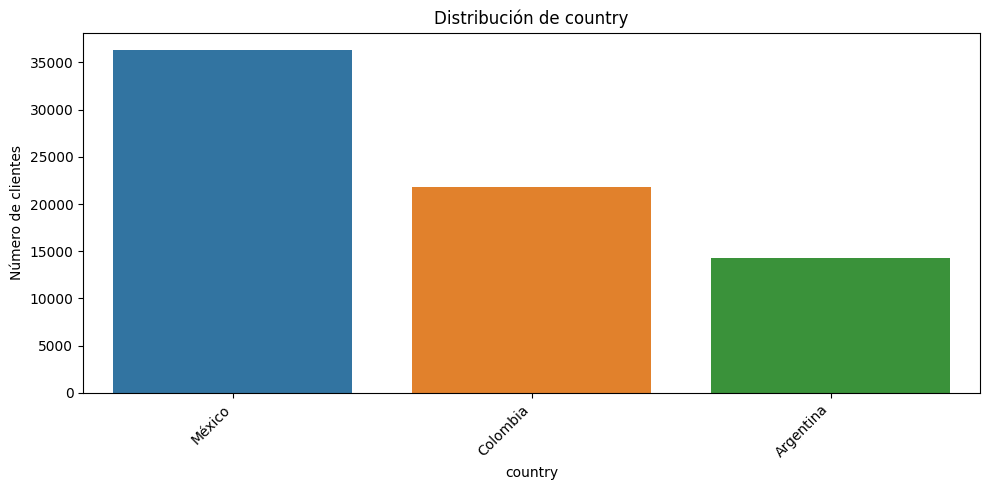

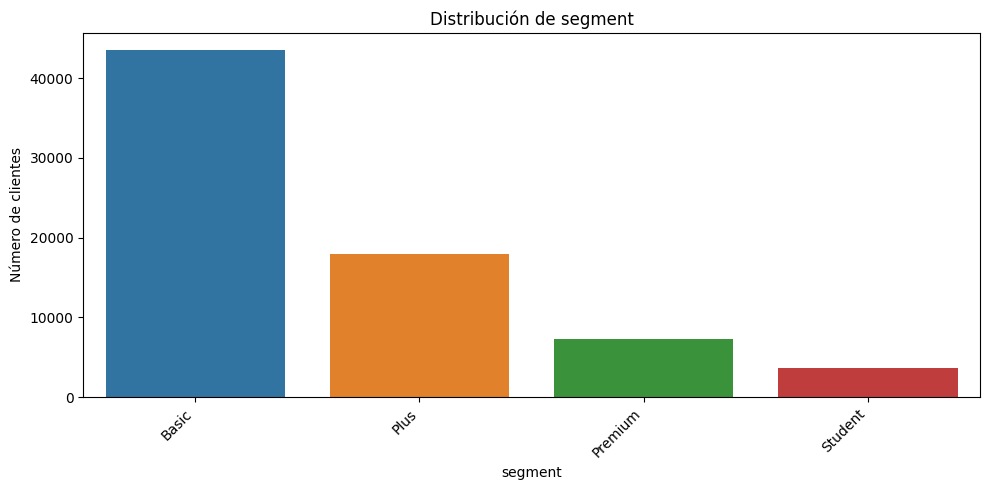

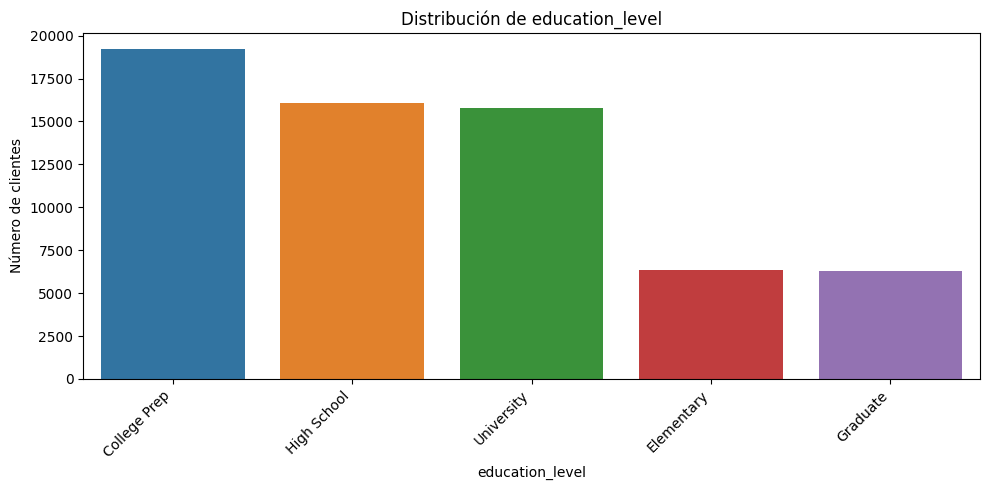

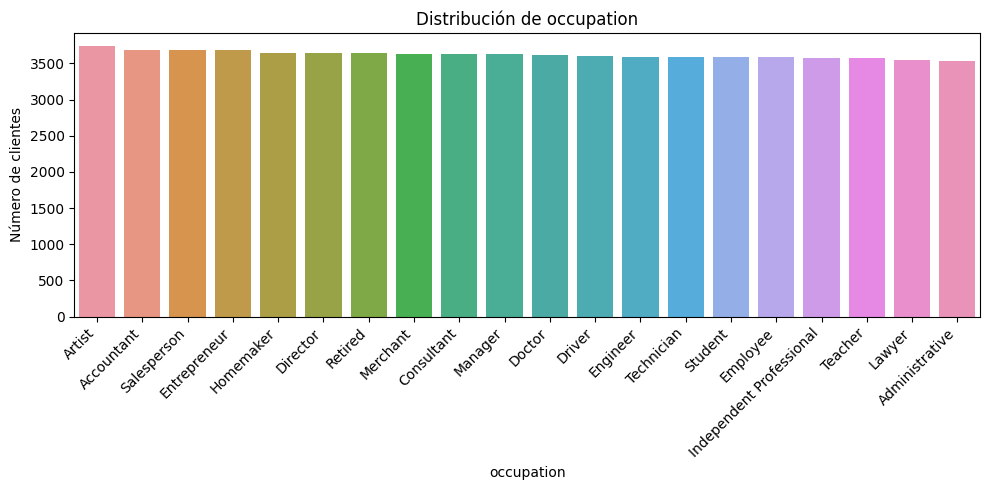

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# 4. EDA UNIVARIADO
# 4.1 VARIABLES CATEGÓRICAS
# ============================================================

categorical_cols = [
    "country",
    "segment",
    "education_level",
    "occupation"
]


# ============================================================
# 1. FRECUENCIAS Y PROPORCIONES
# ============================================================

for col in categorical_cols:

    print("\n" + "=" * 70)
    print(f"VARIABLE: {col}")
    print("=" * 70)

    # Frecuencia absoluta
    frequency = reduced_users_df[col].value_counts(dropna=False)

    # Frecuencia relativa
    percentage = (
        reduced_users_df[col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
    )

    # Tabla resumen
    summary = pd.DataFrame({
        "frecuencia": frequency,
        "porcentaje": percentage.round(2)
    })

    print(summary)
    
# ============================================================
# 3. DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS
# ============================================================

for col in categorical_cols:

    plt.figure(figsize=(10, 5))

    order = reduced_users_df[col].value_counts().index

    sns.countplot(
        data=reduced_users_df,
        x=col,
        order=order
    )

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Número de clientes")

    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()
    

### 3.2 Numerical Variables

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# 4.2 EDA UNIVARIADO
# VARIABLES NUMÉRICAS
# ============================================================
numerical_cols = [
    "credit_score",
    "income_usd",
    "Deuda_usd",
    "Activos_financieros_usd",
    "Edad"
]


# ============================================================
# 1. ESTADÍSTICOS DESCRIPTIVOS
# ============================================================

summary_numeric = reduced_users_df[numerical_cols].describe().T

summary_numeric["normalized_std"]= summary_numeric["std"] / summary_numeric["mean"]

# Agregar medidas adicionales
summary_numeric["missing"] = reduced_users_df[numerical_cols].isna().sum()
summary_numeric["missing_%"] = (
    reduced_users_df[numerical_cols]
    .isna()
    .mean()
    .mul(100)
)

summary_numeric["zeros"] = (
    reduced_users_df[numerical_cols] == 0
).sum()

summary_numeric["zeros_%"] = (
    (reduced_users_df[numerical_cols] == 0)
    .mean()
    .mul(100)
)

summary_numeric["skewness"] = (
    reduced_users_df[numerical_cols]
    .skew()
)

summary_numeric["kurtosis"] = (
    reduced_users_df[numerical_cols]
    .kurtosis()
)

print(summary_numeric)



                           count          mean           std       min  \
credit_score             72380.0    646.658842     76.824304  422.0000   
income_usd               72380.0   5485.068152   6910.080333  280.5154   
Deuda_usd                72380.0  11018.165494  32743.547778    0.0000   
Activos_financieros_usd  72380.0   8455.406959   8237.209405    0.0000   
Edad                     72380.0     52.495662     18.134053   21.0000   

                                 25%          50%           75%  \
credit_score              591.000000   631.000000    694.000000   
income_usd               1646.967850  2565.342450   6631.075687   
Deuda_usd                   0.000000  1521.960589   4243.617959   
Activos_financieros_usd  2589.809206  6490.818952  11817.981205   
Edad                       37.000000    53.000000     68.000000   

                                   max  normalized_std  missing  missing_%  \
credit_score                850.000000        0.118802        0        0.0


Distribución de credit_score por categorías:



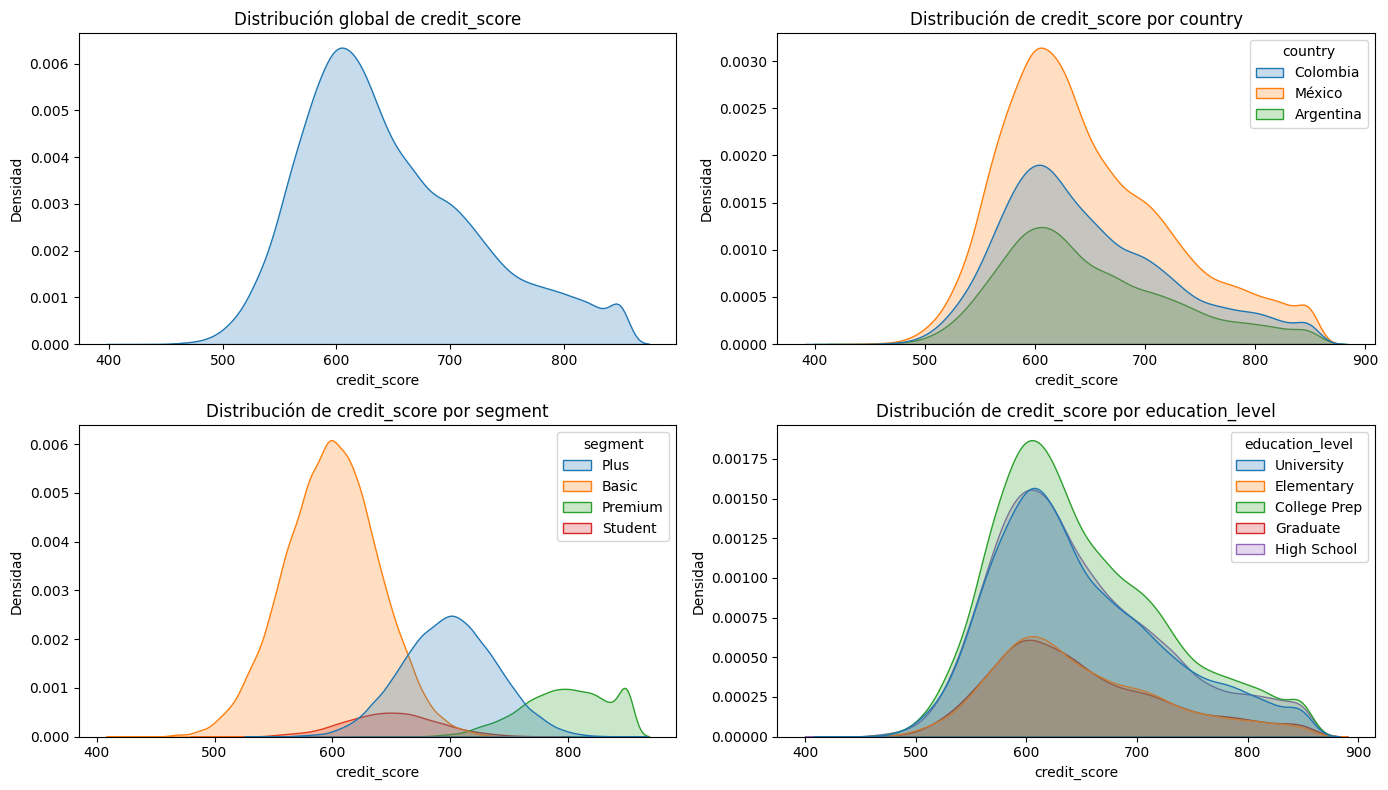


Distribución de income_usd por categorías:



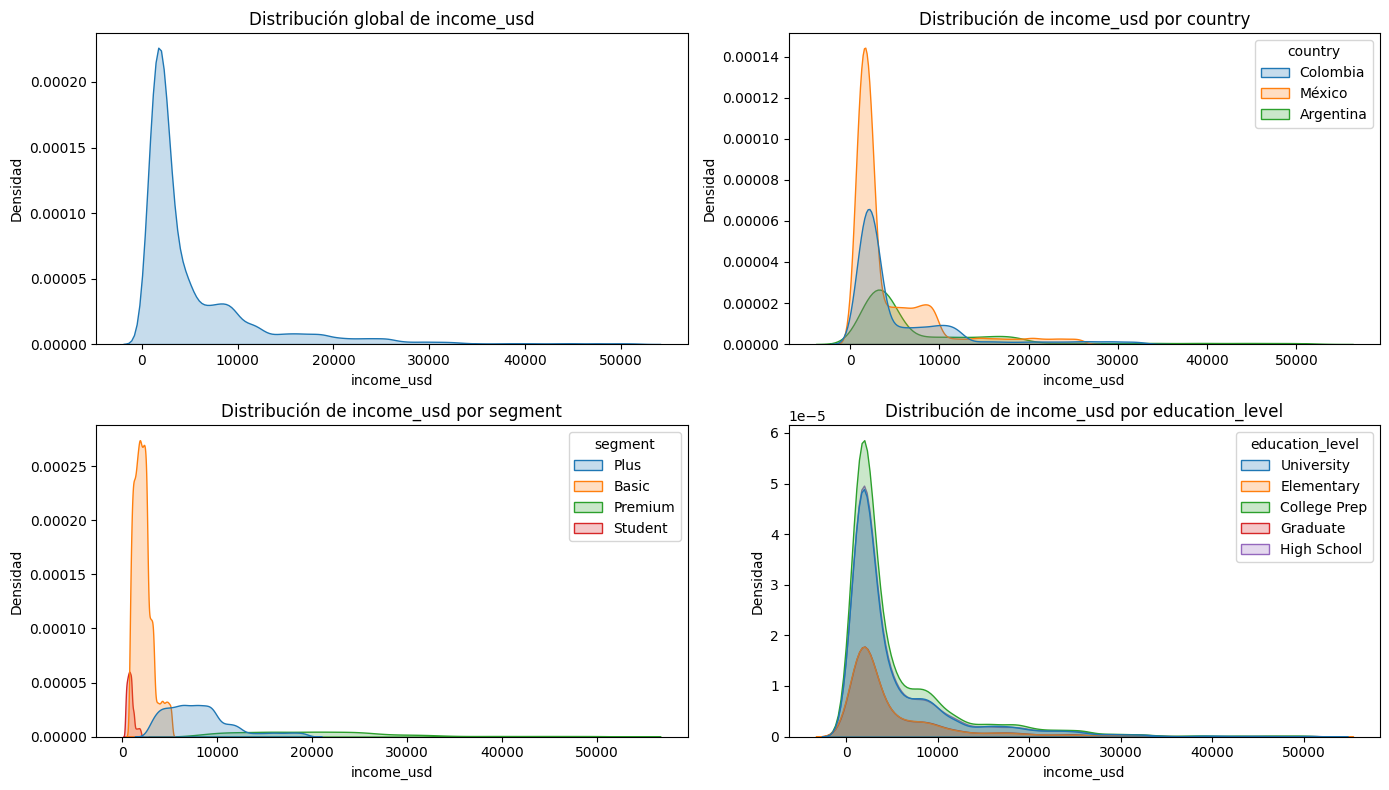


Distribución de Deuda_usd por categorías:



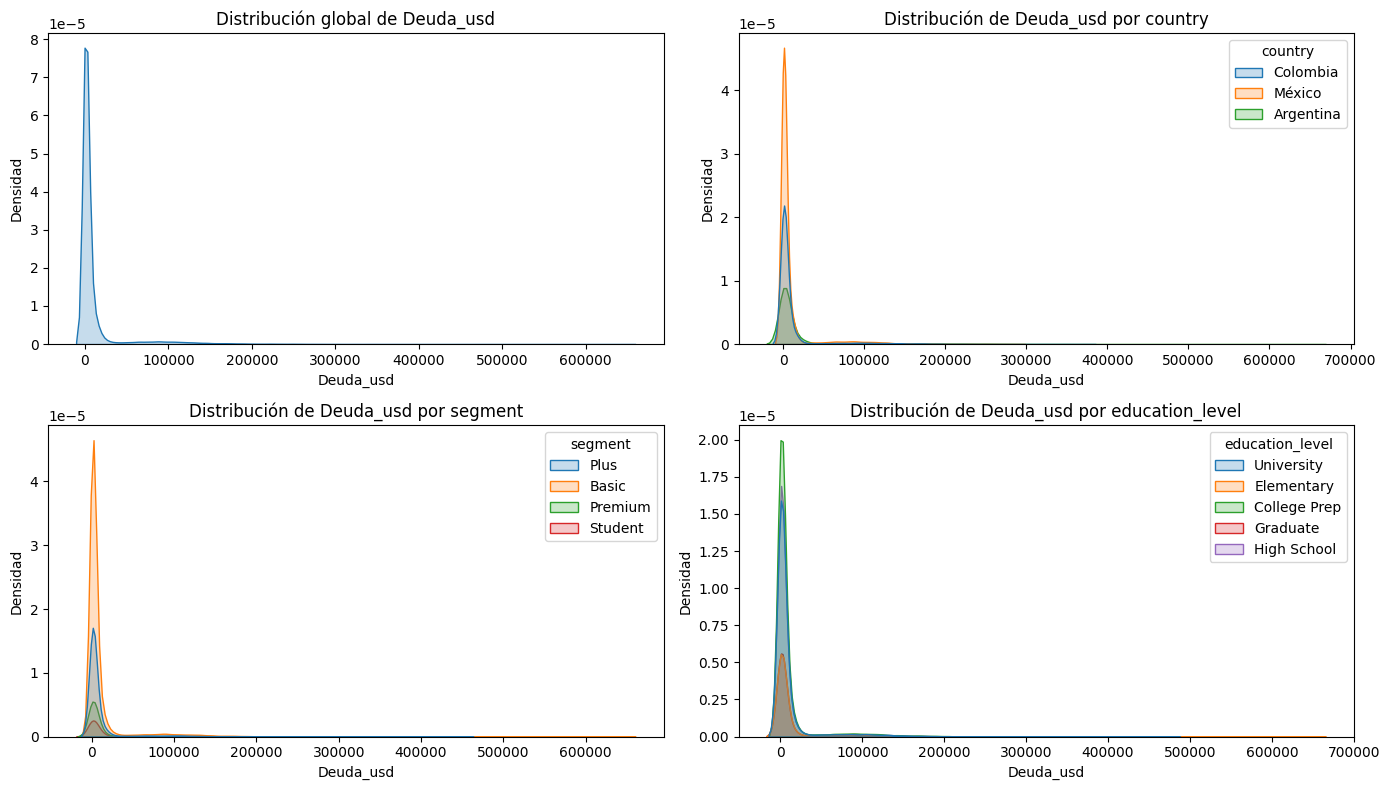


Distribución de Activos_financieros_usd por categorías:



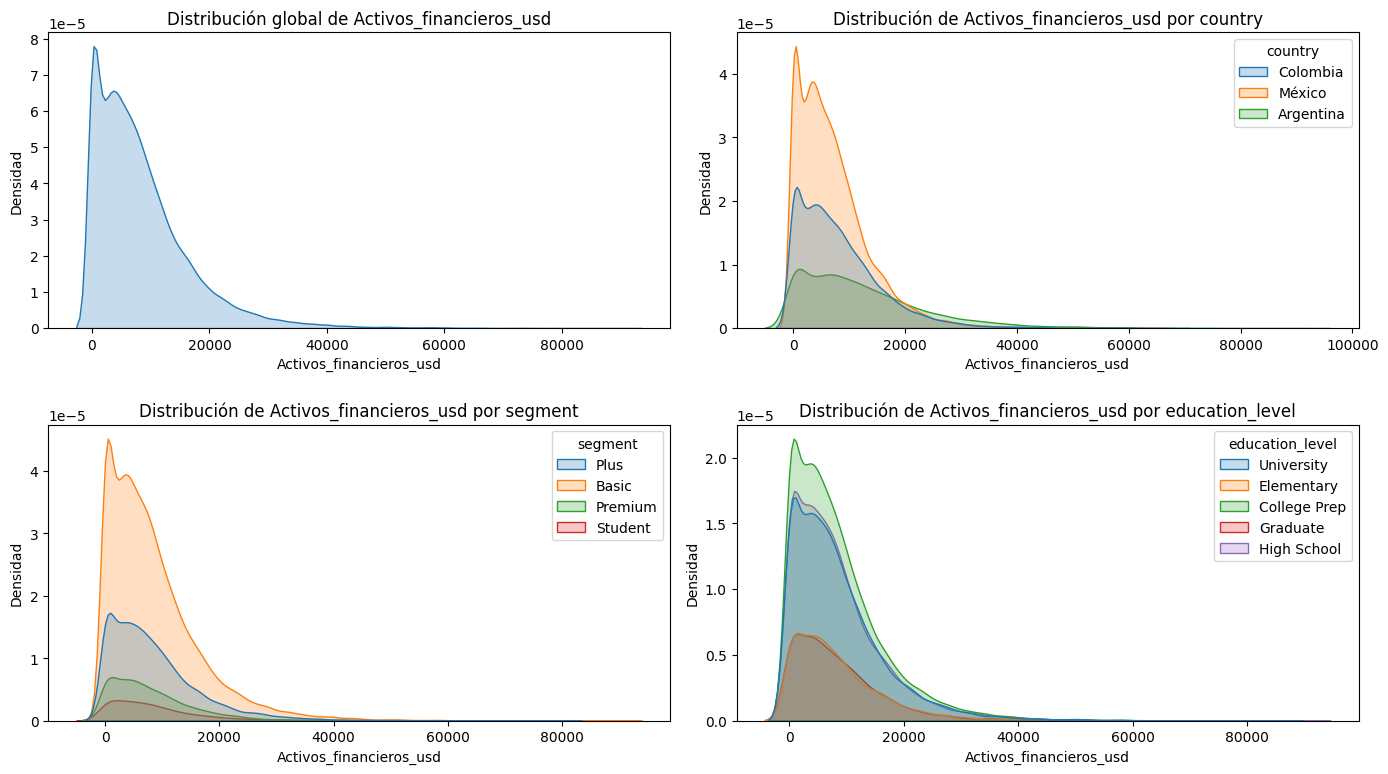


Distribución de Edad por categorías:



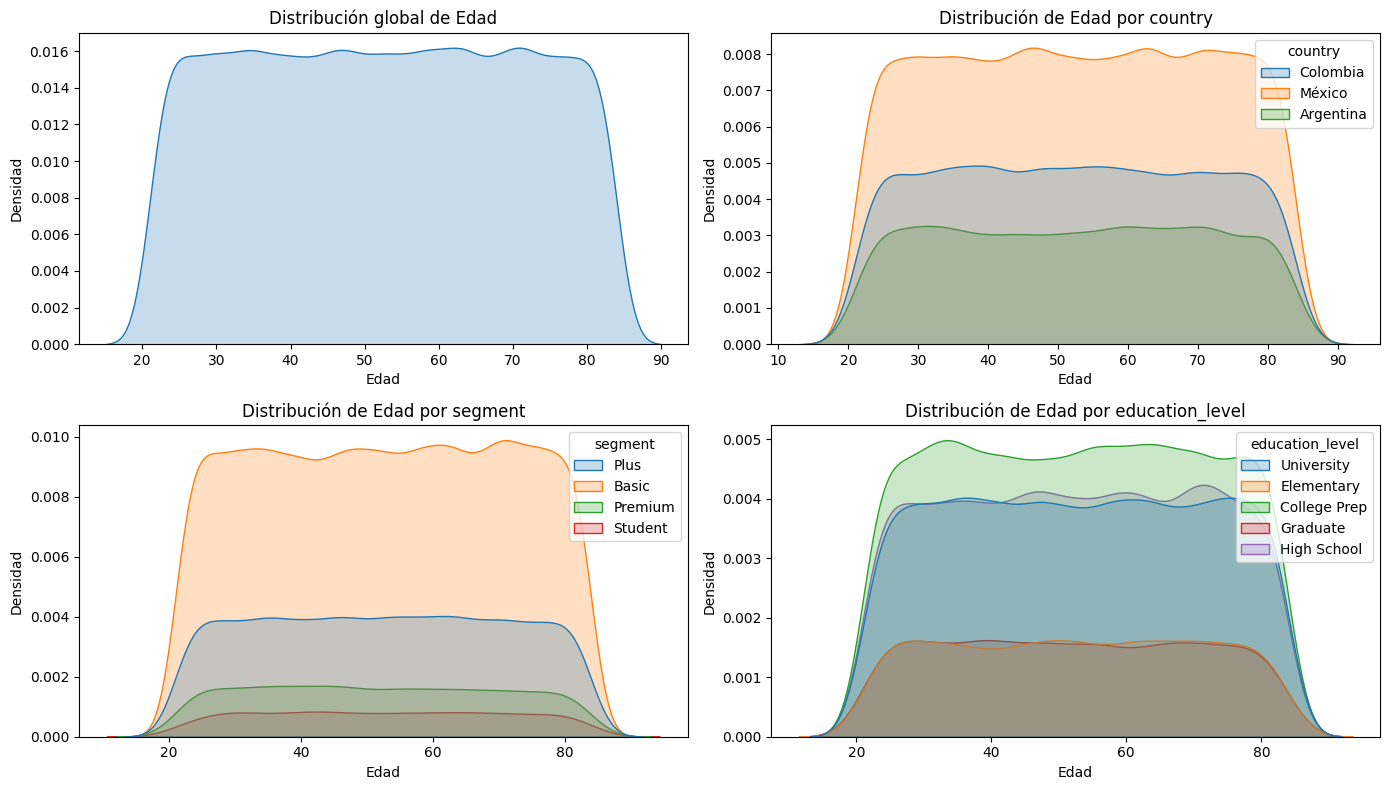

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# Crear figura 2x2
# ============================================================


hue_cols = [
    "country",
    "segment",
    "education_level"
]


for num_col in numerical_cols:
    print(f"\nDistribución de {num_col} por categorías:\n")

    fig, axs = plt.subplots(2, 2, figsize=(14, 8))


    # ============================================================
    # 1. Distribución global de income_usd
    # ============================================================

    sns.kdeplot(
        data=reduced_users_df,
        x=num_col,
        ax=axs[0][0],
        fill=True
    )

    axs[0][0].set_title("Distribución global de " + num_col)
    axs[0][0].set_xlabel(str(num_col))
    axs[0][0].set_ylabel("Densidad")



    sns.kdeplot(
        data=reduced_users_df,
        x=num_col,
        hue=hue_cols[0],
        ax=axs[0][1],
        fill=True,
        common_norm=True
    )

    axs[0][1].set_title("Distribución de {} por {}".format(num_col, hue_cols[0]))
    axs[0][1].set_xlabel(str(num_col))
    axs[0][1].set_ylabel("Densidad")


    sns.kdeplot(
        data=reduced_users_df,
        x=num_col,
        hue=hue_cols[1],
        ax=axs[1][0],
        fill=True,
        common_norm=True
    )

    axs[1][0].set_title("Distribución de {} por {}".format(num_col, hue_cols[1]))
    axs[1][0].set_xlabel(str(num_col))
    axs[1][0].set_ylabel("Densidad")


    # ============================================================
    # 4. Income por Education Level
    # ============================================================

    sns.kdeplot(
        data=reduced_users_df,
        x=num_col,
        hue=hue_cols[2],
        ax=axs[1][1],
        fill=True,
        common_norm=True
    )

    axs[1][1].set_title("Distribución de {} por {}".format(num_col, hue_cols[2]))
    axs[1][1].set_xlabel(str(num_col))
    axs[1][1].set_ylabel("Densidad")


    # ============================================================
    # Ajustar espacios
    # ============================================================

    plt.tight_layout()
    plt.show()


In [27]:
# ============================================================
# 7. ESTADÍSTICOS POR CATEGORÍA
# ============================================================

for num_col in numerical_cols:

    for hue_col in hue_cols:

        print("\n" + "=" * 80)
        print(f"{num_col} por {hue_col}")
        print("=" * 80)

        summary = (
            reduced_users_df
            .groupby(hue_col)[num_col]
            .agg([
                "count",
                "mean",
                "median",
                "std",
                "min",
                "max"
            ])
            .round(2)
        )

        print(summary)


credit_score por country
           count    mean  median    std    min    max
country                                              
Argentina  14312  646.90   631.0  77.14  433.0  850.0
Colombia   21754  646.41   631.0  76.51  422.0  850.0
México     36314  646.71   631.0  76.89  441.0  850.0

credit_score por segment
         count    mean  median    std    min    max
segment                                            
Basic    43509  599.37   600.0  39.98  422.0  780.0
Plus     17942  699.11   699.0  39.81  542.0  850.0
Premium   7321  797.61   800.0  36.79  640.0  850.0
Student   3608  649.75   650.0  40.11  503.0  779.0

credit_score por education_level
                 count    mean  median    std    min    max
education_level                                            
College Prep     19201  647.54   632.0  76.66  449.0  850.0
Elementary        6328  646.30   631.0  75.68  469.0  850.0
Graduate          6312  647.15   632.0  77.47  456.0  850.0
High School      16081  646.53  

### Conclusiones analisis univariado

Se identificaron valores extremos en las distribuciones financieras. Sin embargo, estos valores no fueron eliminados automáticamente, dado que su condición de outlier estadístico no implica necesariamente un error de calidad. Su tratamiento será definido posteriormente considerando su impacto sobre las distancias utilizadas por los algoritmos de clustering.

## 4. Análisis bivariado y multivariado

### Objetivo

Explorar las relaciones entre las variables del conjunto de datos e identificar patrones, asociaciones y estructuras multivariadas que permitan determinar qué características aportan información relevante para la segmentación de los clientes y cuáles pueden ser utilizadas en la construcción del espacio de características para el modelo de clustering.

### Objetivos específicos

* Analizar las relaciones entre variables numéricas y categóricas, identificando diferencias en las distribuciones, tendencias y posibles asociaciones entre los distintos grupos de clientes.

* Evaluar las relaciones entre variables numéricas mediante medidas de correlación lineal y monotónica, con el propósito de identificar asociaciones relevantes, posibles redundancias y relaciones que puedan afectar la construcción del modelo de clustering.

* Analizar la asociación entre variables categóricas para identificar posibles dependencias o relaciones que puedan indicar información redundante.

* Identificar posibles **correlaciones espurias o aparentes**, verificando si las asociaciones observadas pueden estar influenciadas por otras variables o por diferencias en la composición de los grupos.

* Explorar posibles **relaciones no lineales** entre variables que no puedan ser representadas adecuadamente mediante una correlación lineal, pero que puedan contener información útil para diferenciar perfiles de clientes.

* Investigar posibles **variables confusoras** que puedan modificar, explicar u ocultar la relación observada entre otras variables.

* Explorar posibles **interacciones entre variables**, buscando identificar combinaciones de características que permitan diferenciar mejor determinados perfiles de clientes.

* Evaluar la distribución conjunta de las variables para identificar regiones de concentración, patrones, tendencias o estructuras que puedan sugerir la existencia de grupos naturales de clientes.

* Determinar, a partir de la evidencia obtenida, qué variables deben conservarse, transformarse, combinarse o descartarse para construir un espacio de características adecuado para el clustering.


### 4.1 Análisis bivariado Categorical-Categorical

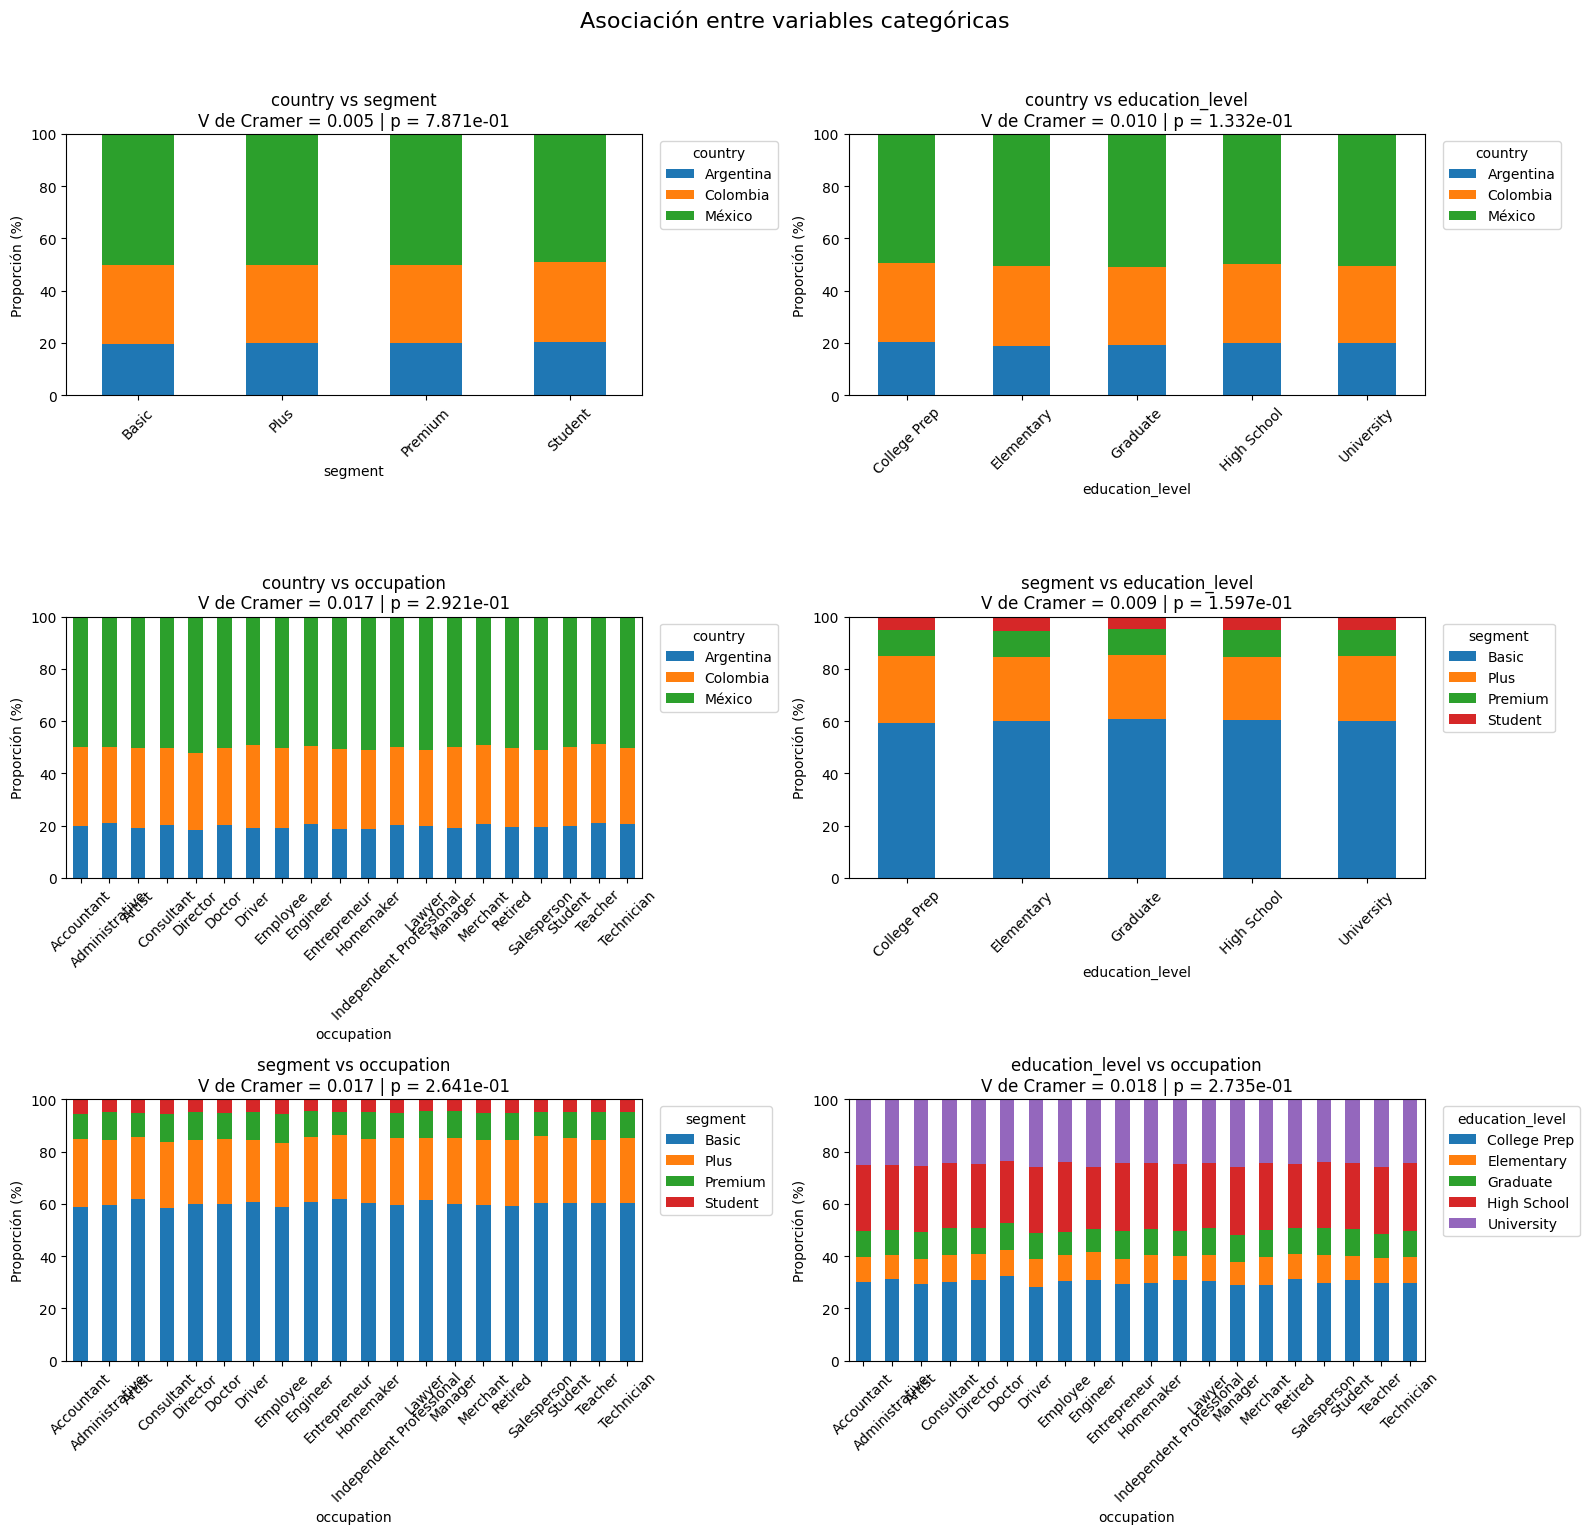

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import chi2_contingency


# ============================================================
# VARIABLES CATEGÓRICAS
# ============================================================

categorical_cols = [
    "country",
    "segment",
    "education_level",
    "occupation"
]


# ============================================================
# COMBINACIONES POSIBLES
# ============================================================

combinations_cat = list(
    combinations(categorical_cols, 2)
)

n_combinations = len(combinations_cat)


# ============================================================
# CONFIGURACIÓN DEL SUBPLOT
# ============================================================

ncols = 2
nrows = int(np.ceil(n_combinations / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 5 * nrows)
)

# Convertir axes en arreglo 1D para recorrerlo fácilmente
axes = np.array(axes).flatten()


# ============================================================
# RECORRER TODAS LAS COMBINACIONES
# ============================================================

for ax, (col1, col2) in zip(axes, combinations_cat):

    # --------------------------------------------------------
    # Tabla de contingencia
    # --------------------------------------------------------

    contingency_table = pd.crosstab(
        reduced_users_df[col1],
        reduced_users_df[col2]
    )

    # --------------------------------------------------------
    # Chi-cuadrado
    # --------------------------------------------------------

    chi2, p, dof, expected = chi2_contingency(
        contingency_table
    )

    # --------------------------------------------------------
    # V de Cramer
    # --------------------------------------------------------

    n = contingency_table.to_numpy().sum()
    min_dim = min(contingency_table.shape) - 1

    cramer_v = np.sqrt(
        chi2 / (n * min_dim)
    )

    # --------------------------------------------------------
    # Normalizar por columnas
    #
    # Cada columna suma 100%.
    # Permite comparar las proporciones internas
    # independientemente del tamaño de cada grupo.
    # --------------------------------------------------------

    proportions = pd.crosstab(
        reduced_users_df[col1],
        reduced_users_df[col2],
        normalize="columns"
    ) * 100

    # --------------------------------------------------------
    # Gráfico
    # --------------------------------------------------------

    proportions.T.plot(
        kind="bar",
        stacked=True,
        ax=ax
    )

    ax.set_title(
        f"{col1} vs {col2}\n"
        f"V de Cramer = {cramer_v:.3f} | p = {p:.3e}"
    )

    ax.set_xlabel(col2)
    ax.set_ylabel("Proporción (%)")

    ax.set_ylim(0, 100)

    ax.legend(
        title=col1,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    ax.tick_params(axis="x", rotation=45)


# ============================================================
# ELIMINAR SUBPLOTS SOBRANTES
# ============================================================

for ax in axes[n_combinations:]:
    ax.remove()


# ============================================================
# AJUSTE FINAL
# ============================================================

plt.suptitle(
    "Asociación entre variables categóricas",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# FUNCIÓN PARA INTERPRETAR V DE CRAMER
# ============================================================

def interpret_cramers_v(v):

    if v < 0.10:
        return "Asociación muy débil"
    elif v < 0.30:
        return "Asociación débil"
    elif v < 0.50:
        return "Asociación moderada"
    elif v < 0.70:
        return "Asociación fuerte"
    else:
        return "Asociación muy fuerte"


# ============================================================
# CALCULAR ASOCIACIONES
# ============================================================

results = []

for col1, col2 in combinations(categorical_cols, 2):

    # Tabla de contingencia
    contingency_table = pd.crosstab(
        reduced_users_df[col1],
        reduced_users_df[col2]
    )

    # Chi-cuadrado
    chi2, p, dof, expected = chi2_contingency(
        contingency_table
    )

    # Tamaño de muestra
    n = contingency_table.to_numpy().sum()

    # Dimensión mínima
    min_dim = min(contingency_table.shape) - 1

    # V de Cramer
    cramer_v = np.sqrt(
        chi2 / (n * min_dim)
    )

    # Interpretación
    interpretation = interpret_cramers_v(cramer_v)

    results.append({
        "Variable A": col1,
        "Variable B": col2,
        "V de Cramer": cramer_v,
        "p-value": p,
        "Interpretación": interpretation
    })


# ============================================================
# CREAR TABLA FINAL
# ============================================================

cramer_results = pd.DataFrame(results)


# Redondear V
cramer_results["V de Cramer"] = (
    cramer_results["V de Cramer"]
    .round(3)
)


# Formatear p-value
cramer_results["p-value"] = cramer_results["p-value"].apply(
    lambda p: "<0.05" if p < 0.05 else round(p, 4)
)


print(cramer_results)

        Variable A       Variable B  V de Cramer  p-value  \
0          country          segment        0.005   0.7871   
1          country  education_level        0.010   0.1332   
2          country       occupation        0.017   0.2921   
3          segment  education_level        0.009   0.1597   
4          segment       occupation        0.017   0.2641   
5  education_level       occupation        0.018   0.2735   

         Interpretación  
0  Asociación muy débil  
1  Asociación muy débil  
2  Asociación muy débil  
3  Asociación muy débil  
4  Asociación muy débil  
5  Asociación muy débil  


### Conclusiones del análisis de asociación entre variables categóricas


El análisis de independencia mediante la prueba Chi-cuadrado y la magnitud de asociación mediante la V de Cramer permitió evaluar las relaciones existentes entre las variables categóricas `country`, `segment`, `education_level` y `occupation`.

Los resultados muestran que la **V de Cramer toma valores entre 0.011 y 0.028 en todas las combinaciones analizadas**, lo que corresponde a asociaciones de magnitud muy baja. Por tanto, no se observa una relación fuerte entre ninguna de las parejas de variables categóricas estudiadas.

Adicionalmente, los valores p obtenidos son superiores a 0.05 en todas las combinaciones:

* `country` – `segment`: V = 0.011, p = 0.2824.
* `country` – `education_level`: V = 0.017, p = 0.0524.
* `country` – `occupation`: V = 0.025, p = 0.5611.
* `segment` – `education_level`: V = 0.015, p = 0.1733.
* `segment` – `occupation`: V = 0.023, p = 0.8448.
* `education_level` – `occupation`: V = 0.028, p = 0.3201.

Bajo un nivel de significancia de α = 0.05, no se encuentra evidencia estadística suficiente para rechazar la hipótesis de independencia en ninguna de las combinaciones analizadas. En particular, la relación entre `country` y `education_level` presenta un valor p de 0.0524, muy cercano al umbral establecido, pero no alcanza el nivel de significancia adoptado.

En conjunto, los resultados sugieren que las variables categóricas presentan **baja dependencia entre sí y poca redundancia desde el punto de vista de su asociación bivariada**. Esto permite conservarlas para las siguientes etapas del análisis sin identificar, a partir de este estudio, una necesidad de excluir alguna variable debido exclusivamente a su asociación con otra variable categórica.

Sin embargo, la baja asociación entre variables categóricas **no implica que todas aporten información relevante para la segmentación**. Una variable puede ser independiente de las demás variables categóricas y, al mismo tiempo, no proporcionar una diferenciación significativa de los clientes en el espacio financiero. Por esta razón, la utilidad de estas variables para el clustering deberá evaluarse posteriormente mediante su relación con las variables numéricas y mediante el análisis multivariado.

### Decisión para la siguiente etapa

Las variables categóricas se mantendrán inicialmente en el conjunto de análisis. No se eliminarán por redundancia categórica, ya que no se encontró evidencia de asociaciones fuertes entre ellas.

El siguiente análisis se enfocará en estudiar las relaciones entre **variables numéricas y categóricas**, con el objetivo de determinar si estas variables permiten diferenciar grupos de clientes según características como `income_usd`, `credit_score`, `Deuda_usd`, `Activos_financieros_usd` y `Edad`.


### 4.2 Análisis bivariado Categorical-Numerical

In [33]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, kruskal

# ============================================================
# 1. Orden ordinal de segment
# ============================================================

segment_order = {
    "Student": 1,
    "Basic": 2,
    "Plus": 3,
    "Premium": 4
}

df = reduced_users_df[["segment", "income_usd"]].copy()

# Convertir segment a escala ordinal
df["segment_ordinal"] = df["segment"].map(segment_order)

# Eliminar valores faltantes
df = df.dropna(subset=["segment_ordinal", "income_usd"])


# ============================================================
# 2. Correlación de Spearman
# ============================================================

rho, p_value = spearmanr(
    df["segment_ordinal"],
    df["income_usd"]
)

print("=" * 70)
print("CORRELACIÓN SPEARMAN: SEGMENT vs INCOME_USD")
print("=" * 70)

print(f"Spearman rho : {rho:.4f}")
print(f"p-value      : {p_value:.4e}")


# ============================================================
# 3. Interpretación de la magnitud
# ============================================================

abs_rho = abs(rho)

if abs_rho < 0.10:
    strength = "muy débil"
elif abs_rho < 0.30:
    strength = "débil"
elif abs_rho < 0.50:
    strength = "moderada"
elif abs_rho < 0.70:
    strength = "fuerte"
else:
    strength = "muy fuerte"

direction = "positiva" if rho > 0 else "negativa"

print(f"Fuerza       : {strength}")
print(f"Dirección    : {direction}")

if p_value < 0.05:
    print("Resultado    : asociación estadísticamente significativa.")
else:
    print("Resultado    : no se evidencia asociación estadísticamente significativa.")

CORRELACIÓN SPEARMAN: SEGMENT vs INCOME_USD
Spearman rho : 0.8514
p-value      : 0.0000e+00
Fuerza       : muy fuerte
Dirección    : positiva
Resultado    : asociación estadísticamente significativa.


In [34]:
from scipy.stats import f_oneway

# ============================================================
# 4. Correlación eta
# ============================================================

groups = [
    group["income_usd"].values
    for _, group in df.groupby("segment")
]

# ANOVA para obtener la descomposición de varianza
f_stat, p_anova = f_oneway(*groups)

# Media global
grand_mean = df["income_usd"].mean()

# Suma de cuadrados total
ss_total = np.sum(
    (df["income_usd"] - grand_mean) ** 2
)

# Suma de cuadrados entre grupos
ss_between = sum(
    len(group) * (group["income_usd"].mean() - grand_mean) ** 2
    for _, group in df.groupby("segment")
)

# Eta
eta = np.sqrt(ss_between / ss_total)

print()
print("=" * 70)
print("ETA: SEGMENT vs INCOME_USD")
print("=" * 70)

print(f"Eta          : {eta:.4f}")
print(f"Eta²         : {eta**2:.4f}")
print(f"p-value ANOVA: {p_anova:.4e}")


ETA: SEGMENT vs INCOME_USD
Eta          : 0.8567
Eta²         : 0.7340
p-value ANOVA: 0.0000e+00


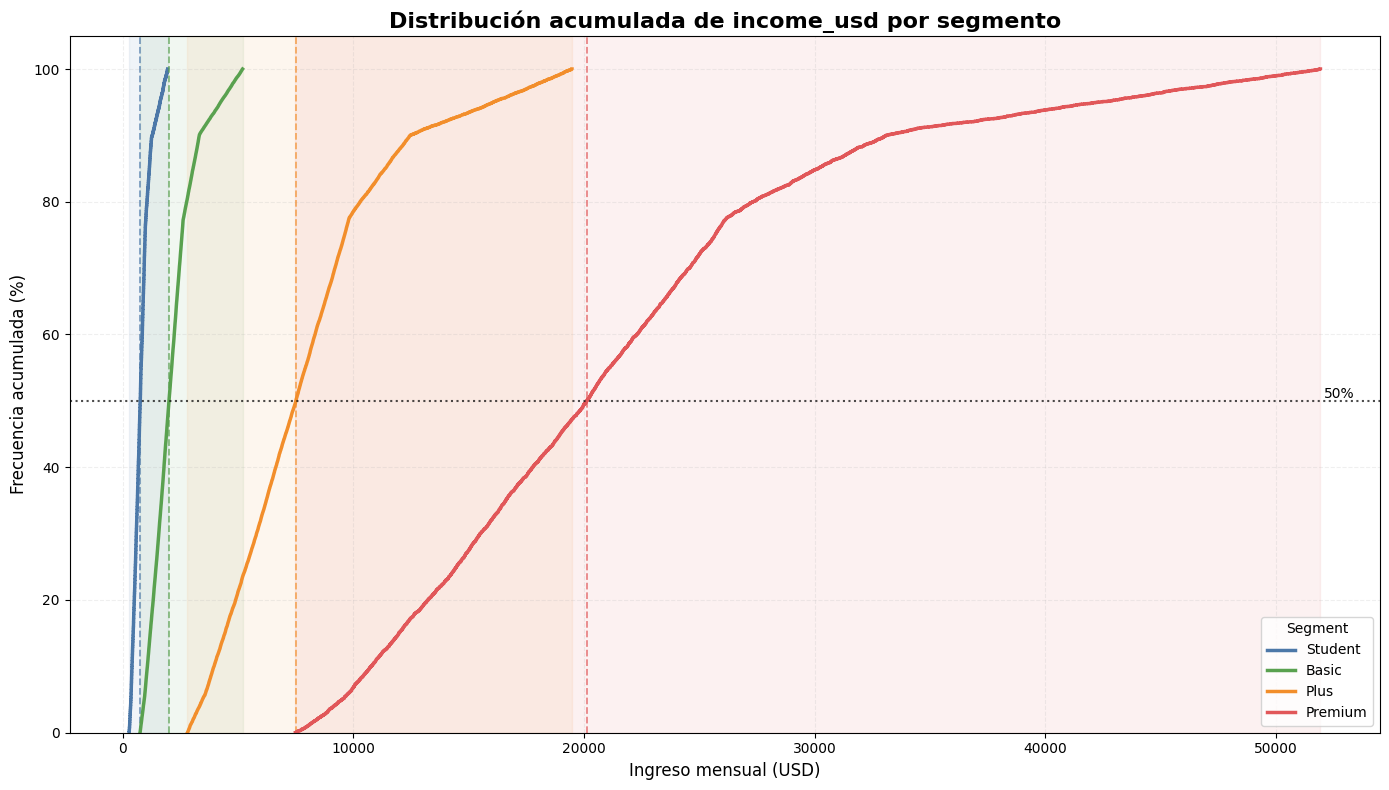

In [36]:
# ============================================================
# 1. Orden lógico de los segmentos
# ============================================================

segment_order = [
    "Student",
    "Basic",
    "Plus",
    "Premium"
]


# ============================================================
# 2. Colores por segmento
# ============================================================

colors = {
    "Student": "#4C78A8",
    "Basic": "#59A14F",
    "Plus": "#F28E2B",
    "Premium": "#E15759"
}


# ============================================================
# 3. Crear figura
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))


# ============================================================
# 4. ECDF + rango de influencia
# ============================================================

for segment in segment_order:

    values = (
        reduced_users_df.loc[
            reduced_users_df["segment"] == segment,
            "income_usd"
        ]
        .dropna()
        .sort_values()
        .values
    )

    n = len(values)

    # Frecuencia acumulada relativa
    cumulative = np.arange(1, n + 1) / n

    # Estadísticos
    min_value = values.min()
    max_value = values.max()
    median_value = np.median(values)

    # --------------------------------------------------------
    # Área de influencia: min -> max
    # --------------------------------------------------------

    ax.axvspan(
        min_value,
        max_value,
        color=colors[segment],
        alpha=0.08
    )

    # --------------------------------------------------------
    # Curva ECDF
    # --------------------------------------------------------

    ax.step(
        values,
        cumulative * 100,
        where="post",
        linewidth=2.5,
        color=colors[segment],
        label=segment
    )

    # --------------------------------------------------------
    # Línea de la mediana
    # --------------------------------------------------------

    ax.axvline(
        median_value,
        color=colors[segment],
        linestyle="--",
        linewidth=1.3,
        alpha=0.7
    )


# ============================================================
# 5. Línea del 50 %
# ============================================================

ax.axhline(
    50,
    color="black",
    linestyle=":",
    linewidth=1.5,
    alpha=0.7
)

ax.text(
    ax.get_xlim()[1] * 0.98,
    50,
    "50%",
    ha="right",
    va="bottom"
)


# ============================================================
# 6. Formato
# ============================================================

ax.set_title(
    "Distribución acumulada de income_usd por segmento",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel(
    "Ingreso mensual (USD)",
    fontsize=12
)

ax.set_ylabel(
    "Frecuencia acumulada (%)",
    fontsize=12
)

ax.set_ylim(0, 105)

ax.grid(
    alpha=0.2,
    linestyle="--"
)

ax.legend(
    title="Segment",
    loc="lower right"
)

plt.tight_layout()
plt.show()

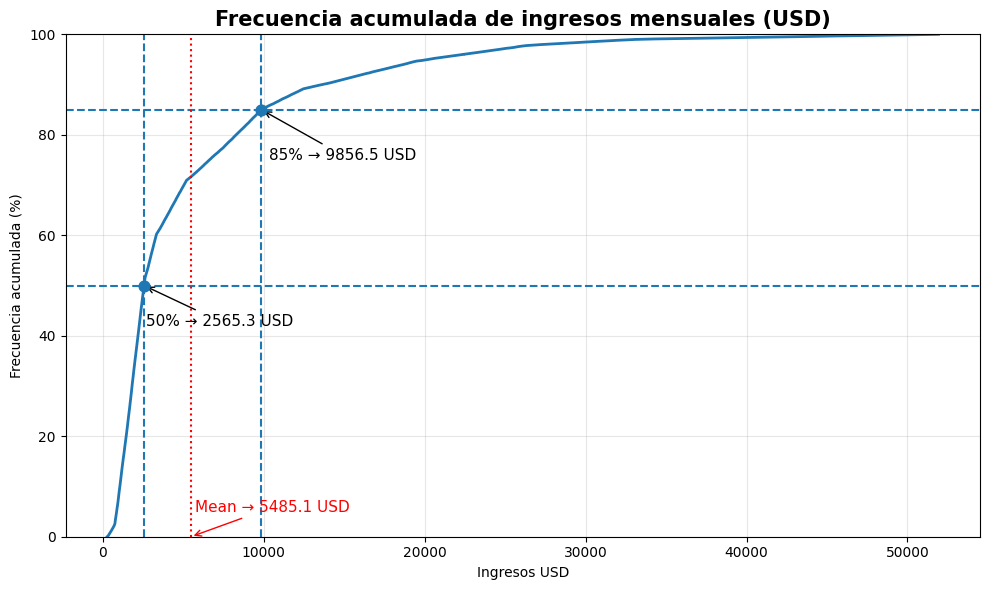

ingresos correspondiente al 50% acumulado: 2565.34 USD
ingresos correspondiente al 85% acumulado: 9856.45 USD


In [39]:
#diagrama de frecuencia acumulada 

# ============================================================
# Datos
# ============================================================

income = reduced_users_df["income_usd"].dropna().sort_values()

# Frecuencia acumulada relativa
frecuencia_acumulada = np.arange(1, len(income) + 1) / len(income)

# ============================================================
# Valores de área correspondientes al 50% y 85%
# ============================================================

income_50 = income.quantile(0.50)
income_85 = income.quantile(0.85)

# ============================================================
# Gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    income,
    frecuencia_acumulada * 100,
    linewidth=2
)

# Línea horizontal 50%
ax.axhline(
    50,
    linestyle="--",
    linewidth=1.5
)

# Línea horizontal 85%
ax.axhline(
    85,
    linestyle="--",
    linewidth=1.5
)

# Línea vertical correspondiente al 50%
ax.axvline(
    income_50,
    linestyle="--",
    linewidth=1.5
)

# Línea vertical correspondiente al 85%
ax.axvline(
    income_85,
    linestyle="--",
    linewidth=1.5
)

# Puntos de intersección
ax.scatter(
    [income_50, income_85],
    [50, 85],
    s=60,
    zorder=5
)

# ============================================================
# Etiquetas
# ============================================================

ax.set_title(
    "Frecuencia acumulada de ingresos mensuales (USD)",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Ingresos USD")
ax.set_ylabel("Frecuencia acumulada (%)")

ax.set_ylim(0, 100)

ax.grid(
    True,
    alpha=0.3
)

# ============================================================
# Anotaciones
# ============================================================

ax.annotate(
    f"50% → {income_50:.1f} USD",
    xy=(income_50, 50),
    xytext=(income_50 * 1.05, 42),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

ax.annotate(
    f"85% → {income_85:.1f} USD",
    xy=(income_85, 85),
    xytext=(income_85 * 1.05, 75),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

#dibujar linea vertical con el mean 

mean_income = income.mean()

ax.axvline(

    mean_income,
    color="red",
    linestyle=":",
    linewidth=1.5,
    label=f"Mean: {mean_income:.2f} USD"
)


ax.annotate(
    f"Mean → {mean_income:.1f} USD",
    xy=(mean_income, 0),
    xytext=(mean_income * 1.05, 5),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=11,
    color="red"
)


plt.tight_layout()
plt.show()

# Mostrar valores
print(f"ingresos correspondiente al 50% acumulado: {income_50:.2f} USD")
print(f"ingresos correspondiente al 85% acumulado: {income_85:.2f} USD")

In [67]:
df = reduced_users_df[["segment", "credit_score"]].copy()


groups = [
    group["credit_score"].values
    for _, group in df.groupby("segment")
]

# ANOVA para obtener la descomposición de varianza
f_stat, p_anova = f_oneway(*groups)

# Media global
grand_mean = df["credit_score"].mean()

# Suma de cuadrados total
ss_total = np.sum(
    (df["credit_score"] - grand_mean) ** 2
)

# Suma de cuadrados entre grupos
ss_between = sum(
    len(group) * (group["credit_score"].mean() - grand_mean) ** 2
    for _, group in df.groupby("segment")
)

# Eta
eta = np.sqrt(ss_between / ss_total)

print()
print("=" * 70)
print("ETA: SEGMENT vs credit_score")
print("=" * 70)

print(f"Eta          : {eta:.4f}")
print(f"Eta²         : {eta**2:.4f}")
print(f"p-value ANOVA: {p_anova:.4e}")


ETA: SEGMENT vs credit_score
Eta          : 0.8573
Eta²         : 0.7350
p-value ANOVA: 0.0000e+00


### 4.3 Análisis bivariado Numerical-Numerical

In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr


# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

numeric_cols = [
    "credit_score",
    "income_usd",
    "Deuda_usd",
    "Activos_financieros_usd",
    "Edad"
]

categorical_cols = [
    "country",
    "segment",
    "education_level",
    "occupation"
]

RANDOM_STATE = 42
PAIRPLOT_SAMPLE = 50000


# ============================================================
# 2. PREPARAR DATASET
# ============================================================

df = reduced_users_df.copy()

# ------------------------------------------------------------
# Verificar que las columnas existan
# ------------------------------------------------------------

required_cols = numeric_cols + categorical_cols

missing_cols = [
    col for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Faltan las siguientes columnas: {missing_cols}"
    )


# ------------------------------------------------------------
# Verificar duplicados de clientes
# ------------------------------------------------------------

if "customer_id" in df.columns:

    duplicated_customers = df["customer_id"].duplicated().sum()

    print("=" * 70)
    print("VERIFICACIÓN DE CLIENTES")
    print("=" * 70)

    print(f"Filas totales                    : {len(df):,}")
    print(f"Clientes únicos                  : {df['customer_id'].nunique():,}")
    print(f"Filas duplicadas por customer_id : {duplicated_customers:,}")

    # Para este análisis usamos una fila por cliente
    df = df.drop_duplicates(
        subset="customer_id"
    ).copy()

else:

    print(
        "No se encontró customer_id. "
        "Se utilizarán las filas disponibles."
    )


# ============================================================
# 3. DATASET NUMÉRICO
# ============================================================

numeric_df = df[numeric_cols].copy()

numeric_df = numeric_df.dropna(
    subset=numeric_cols
)

print()
print("=" * 70)
print("DATASET PARA CORRELACIÓN NUMÉRICA")
print("=" * 70)

print(f"Observaciones utilizadas: {len(numeric_df):,}")


# ============================================================
# 4. MATRIZ DE CORRELACIÓN PEARSON
# ============================================================

pearson_corr = numeric_df.corr(
    method="pearson"
)

print()
print("=" * 70)
print("MATRIZ DE CORRELACIÓN DE PEARSON")
print("=" * 70)

print(
    pearson_corr.round(3)
)


# ============================================================
# 5. MATRIZ DE CORRELACIÓN SPEARMAN
# ============================================================

spearman_corr = numeric_df.corr(
    method="spearman"
)

print()
print("=" * 70)
print("MATRIZ DE CORRELACIÓN DE SPEARMAN")
print("=" * 70)

print(
    spearman_corr.round(3)
)


# ============================================================
# 6. P-VALUES DE PEARSON Y SPEARMAN
# ============================================================

def correlation_pvalues(data, method="pearson"):

    columns = data.columns

    pvalues = pd.DataFrame(
        np.ones(
            (len(columns), len(columns))
        ),
        index=columns,
        columns=columns
    )

    for i in range(len(columns)):

        for j in range(i + 1, len(columns)):

            x = data.iloc[:, i]
            y = data.iloc[:, j]

            if method == "pearson":

                _, p = pearsonr(x, y)

            elif method == "spearman":

                _, p = spearmanr(x, y)

            else:

                raise ValueError(
                    "method debe ser 'pearson' o 'spearman'"
                )

            pvalues.iloc[i, j] = p
            pvalues.iloc[j, i] = p

    return pvalues


pearson_pvalues = correlation_pvalues(
    numeric_df,
    method="pearson"
)

spearman_pvalues = correlation_pvalues(
    numeric_df,
    method="spearman"
)


print()
print("=" * 70)
print("P-VALUES PEARSON")
print("=" * 70)

print(
    pearson_pvalues.round(6)
)


print()
print("=" * 70)
print("P-VALUES SPEARMAN")
print("=" * 70)

print(
    spearman_pvalues.round(6)
)


# ============================================================
# 7. EXTRAER PARES DE VARIABLES
# ============================================================

pairs = []

for i in range(len(numeric_cols)):

    for j in range(i + 1, len(numeric_cols)):

        var_a = numeric_cols[i]
        var_b = numeric_cols[j]

        pairs.append({

            "Variable A": var_a,

            "Variable B": var_b,

            "Pearson": pearson_corr.loc[
                var_a, var_b
            ],

            "p-value Pearson": pearson_pvalues.loc[
                var_a, var_b
            ],

            "Spearman": spearman_corr.loc[
                var_a, var_b
            ],

            "p-value Spearman": spearman_pvalues.loc[
                var_a, var_b
            ]
        })


correlation_pairs = pd.DataFrame(
    pairs
)


# ------------------------------------------------------------
# Ordenar por magnitud de Spearman
# ------------------------------------------------------------

correlation_pairs["abs_Spearman"] = (
    correlation_pairs["Spearman"].abs()
)

correlation_pairs = (
    correlation_pairs
    .sort_values(
        "abs_Spearman",
        ascending=False
    )
    .drop(
        columns="abs_Spearman"
    )
    .reset_index(drop=True)
)


print()
print("=" * 70)
print("PARES DE VARIABLES ORDENADOS POR |SPEARMAN|")
print("=" * 70)

print(
    correlation_pairs.round(4)
)

VERIFICACIÓN DE CLIENTES
Filas totales                    : 72,380
Clientes únicos                  : 72,380
Filas duplicadas por customer_id : 0

DATASET PARA CORRELACIÓN NUMÉRICA
Observaciones utilizadas: 72,380

MATRIZ DE CORRELACIÓN DE PEARSON
                         credit_score  income_usd  Deuda_usd  \
credit_score                    1.000       0.697      0.002   
income_usd                      0.697       1.000      0.019   
Deuda_usd                       0.002       0.019      1.000   
Activos_financieros_usd        -0.007       0.051     -0.009   
Edad                           -0.005      -0.010      0.000   

                         Activos_financieros_usd   Edad  
credit_score                              -0.007 -0.005  
income_usd                                 0.051 -0.010  
Deuda_usd                                 -0.009  0.000  
Activos_financieros_usd                    1.000  0.003  
Edad                                       0.003  1.000  

MATRIZ DE CORRELAC

country: 50,001 observaciones utilizadas


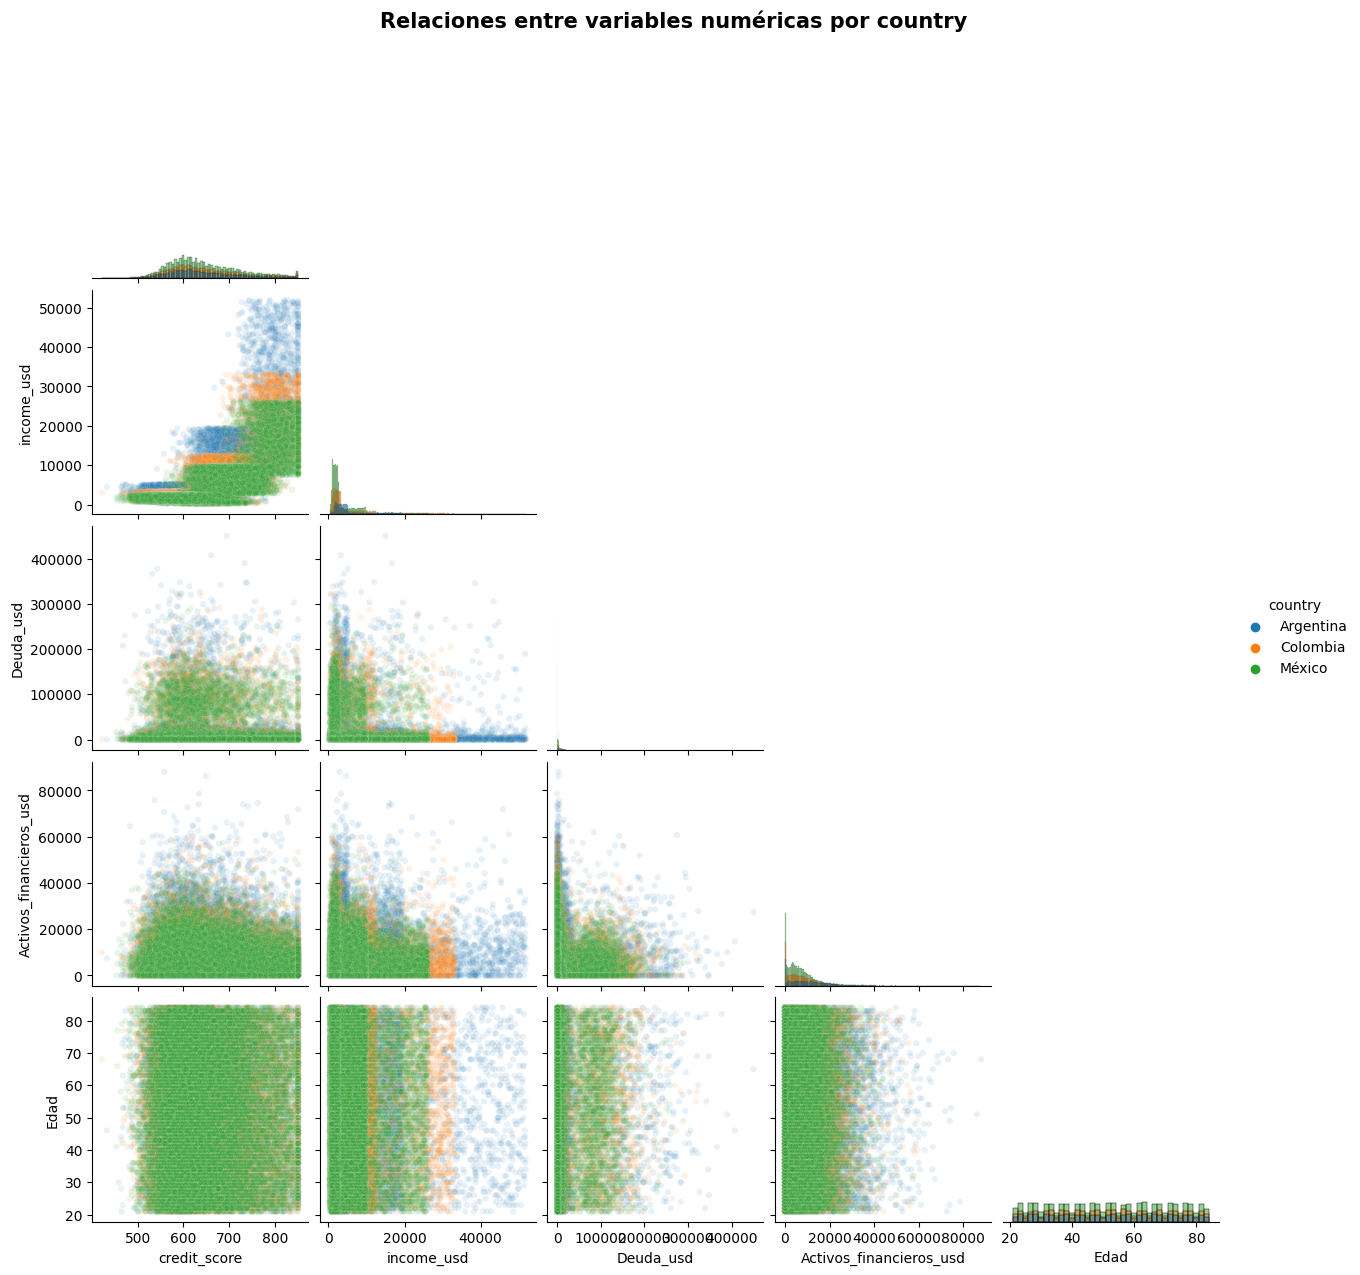

segment: 49,999 observaciones utilizadas


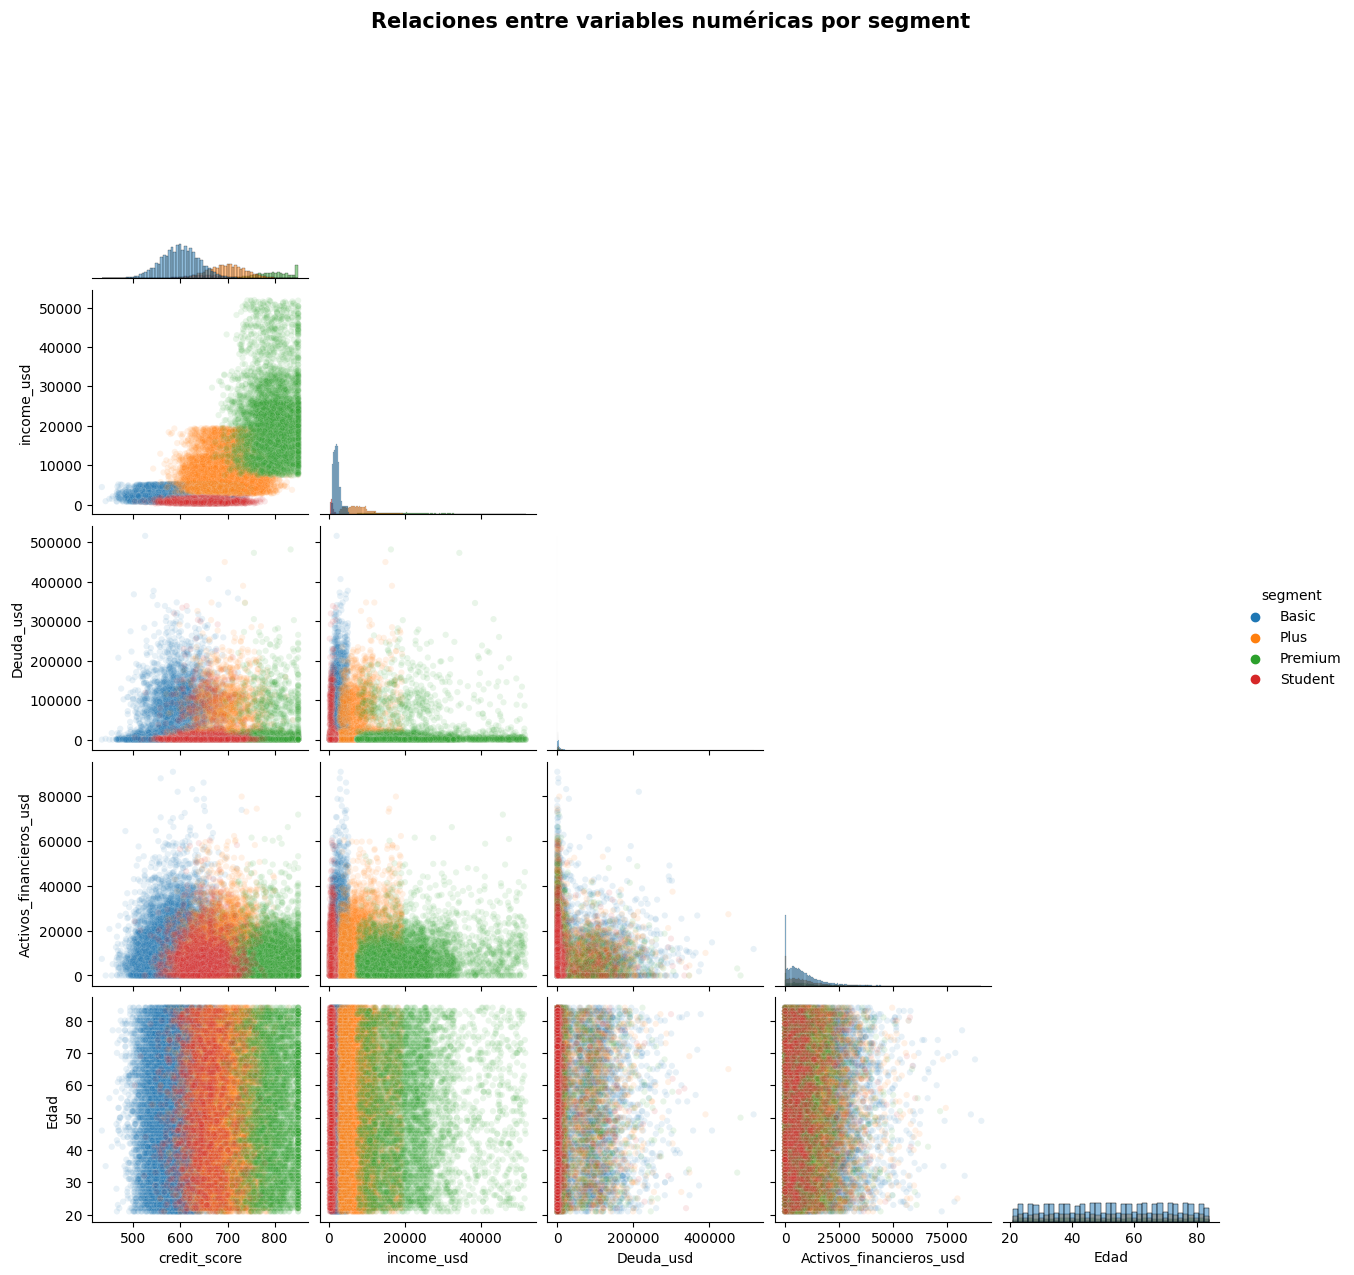

education_level: 50,000 observaciones utilizadas


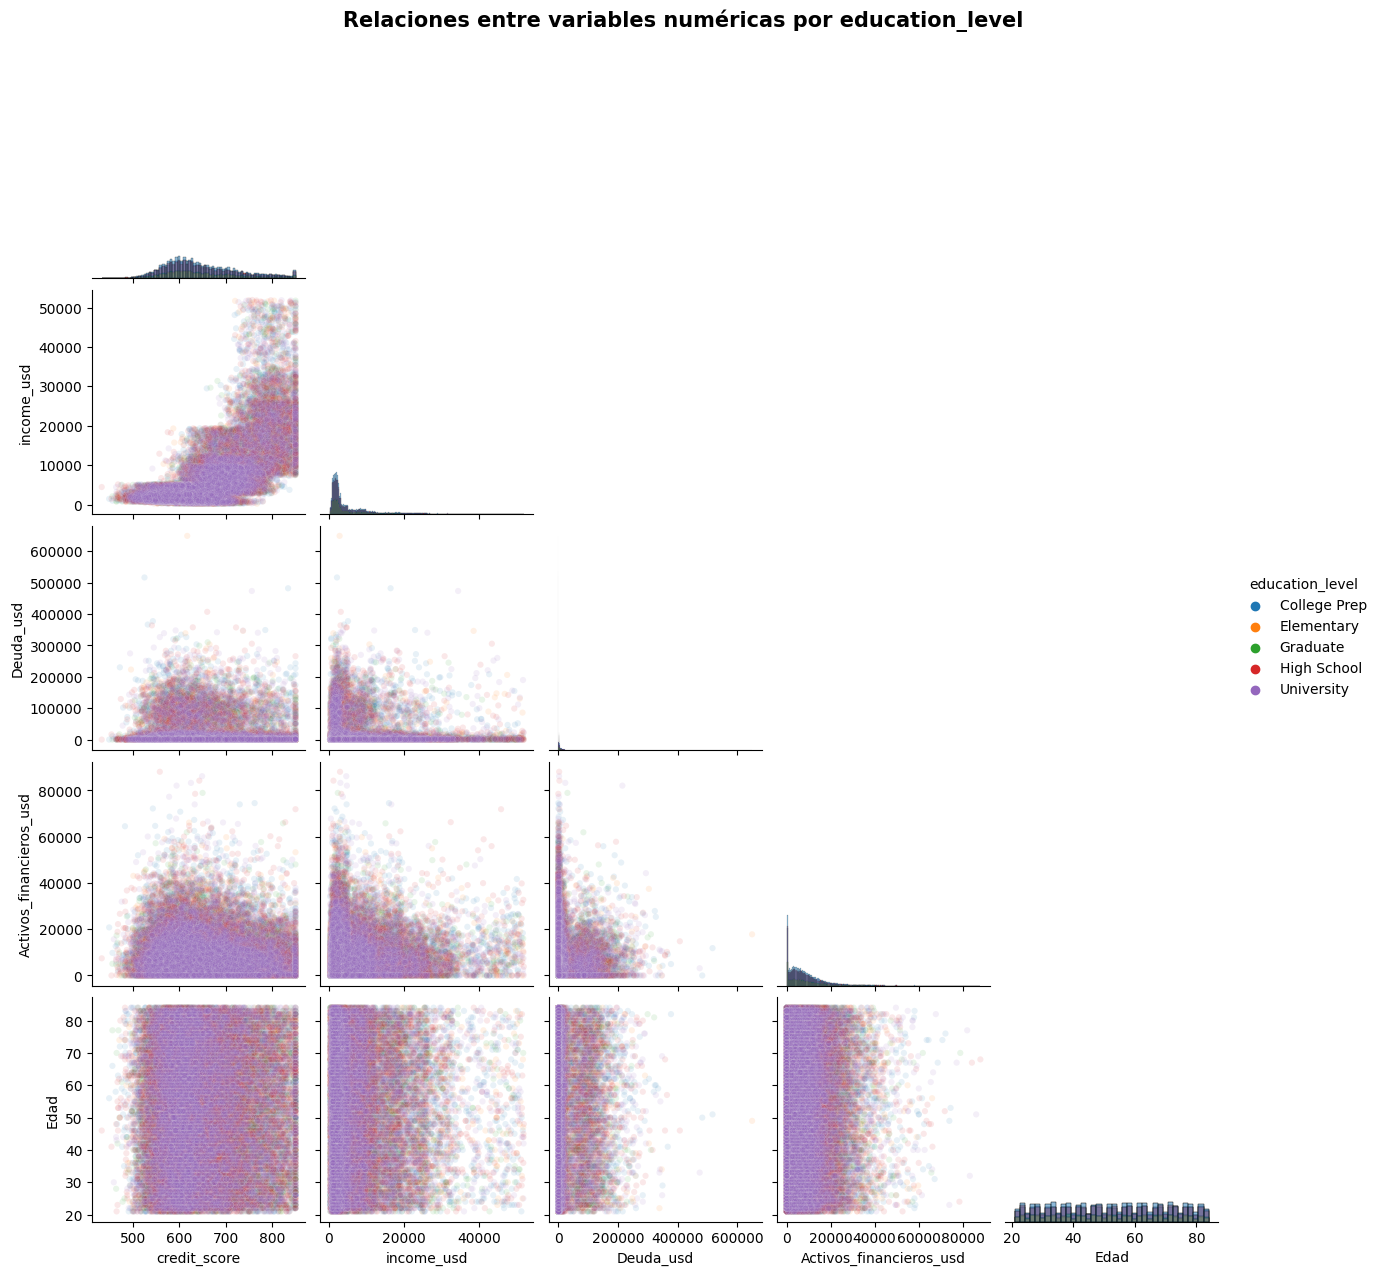

In [43]:
# ============================================================
# 10. FUNCIÓN PARA GENERAR PAIRPLOT
# ============================================================

def plot_pairplot_by_hue(
    data,
    numeric_columns,
    hue_column,
    sample_size=50000,
    random_state=42
):

    plot_df = data[
        numeric_columns + [hue_column]
    ].dropna().copy()

    # --------------------------------------------------------
    # Muestreo proporcional
    # --------------------------------------------------------

    if len(plot_df) > sample_size:

        fraction = sample_size / len(plot_df)

        plot_df = (
            plot_df
            .groupby(
                hue_column,
                group_keys=False
            )
            .sample(
                frac=fraction,
                random_state=random_state
            )
        )

    print(
        f"{hue_column}: "
        f"{len(plot_df):,} observaciones utilizadas"
    )

    # --------------------------------------------------------
    # Pairplot
    # --------------------------------------------------------

    g = sns.pairplot(
        plot_df,
        vars=numeric_columns,
        hue=hue_column,
        corner=True,
        diag_kind="hist",
        plot_kws={
            "alpha": 0.1,
            "s": 20
        }
    )

    g.fig.suptitle(
        f"Relaciones entre variables numéricas por {hue_column}",
        y=1.02,
        fontsize=15,
        fontweight="bold"
    )

    plt.show()


# ============================================================
# 11. PAIRPLOTS
# ============================================================

for categorical in [
    "country",
    "segment",
    "education_level"
]:

    plot_pairplot_by_hue(
        df,
        numeric_cols,
        categorical,
        sample_size=PAIRPLOT_SAMPLE,
        random_state=RANDOM_STATE
    )

tranformación logaritmica


Distribución de income_usd_log por categorías:



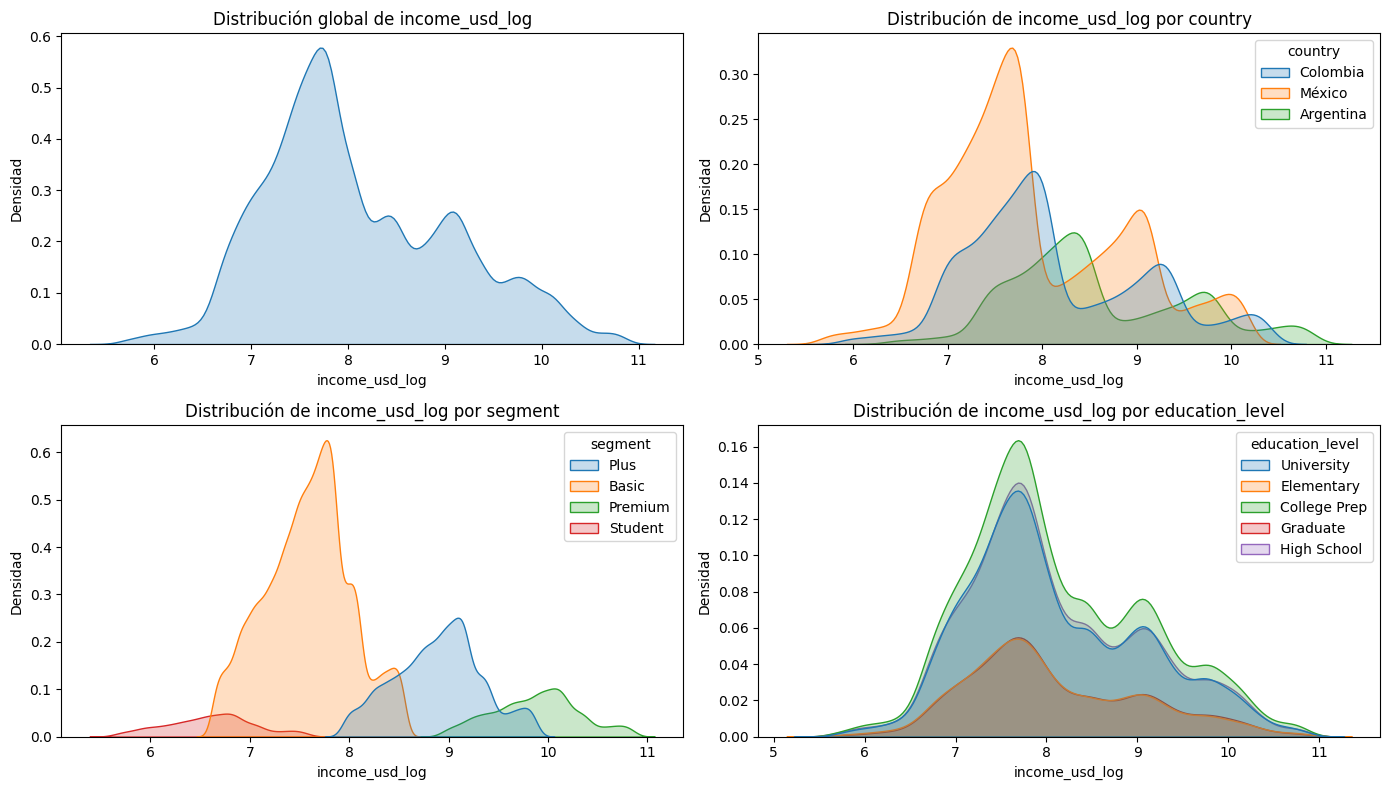


Distribución de credit_score_log por categorías:



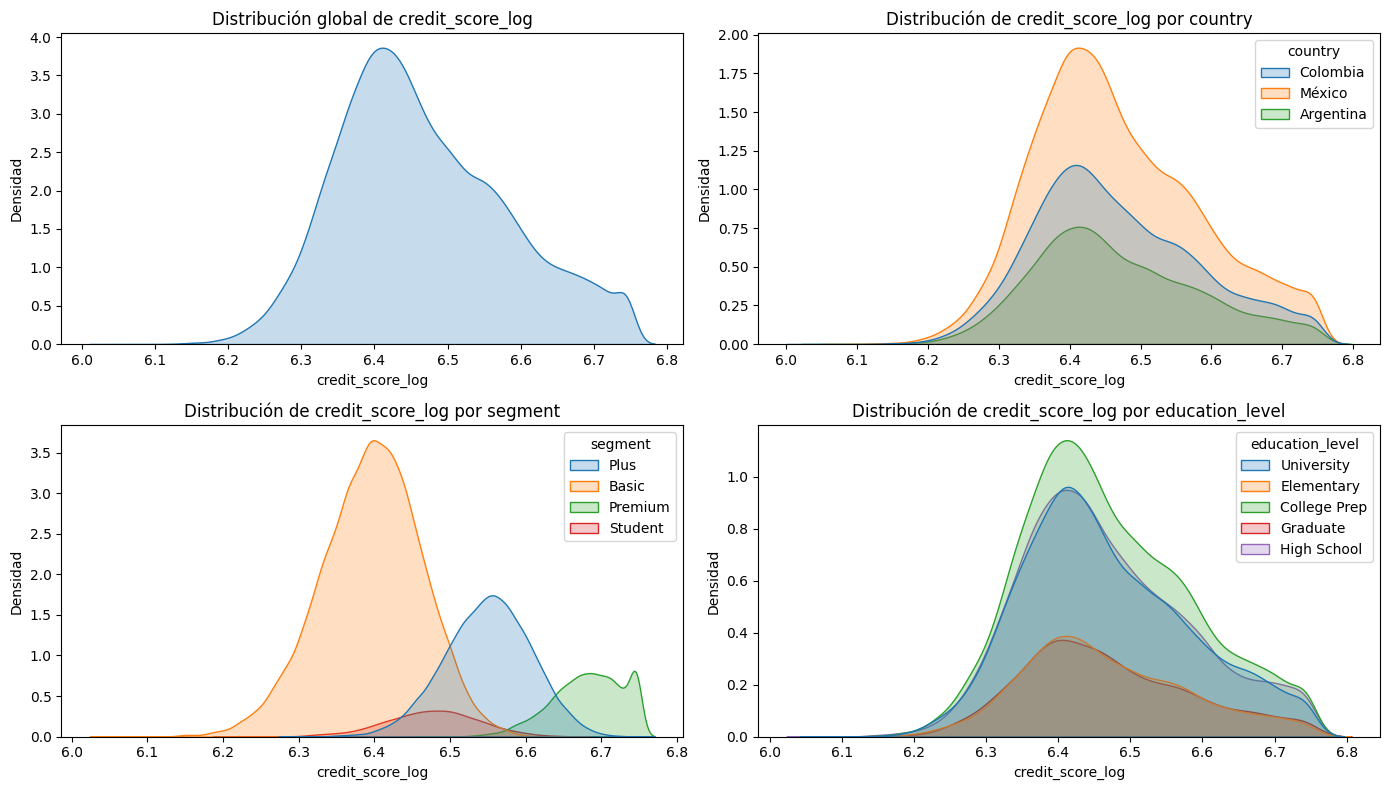


Distribución de Deuda_usd_log por categorías:



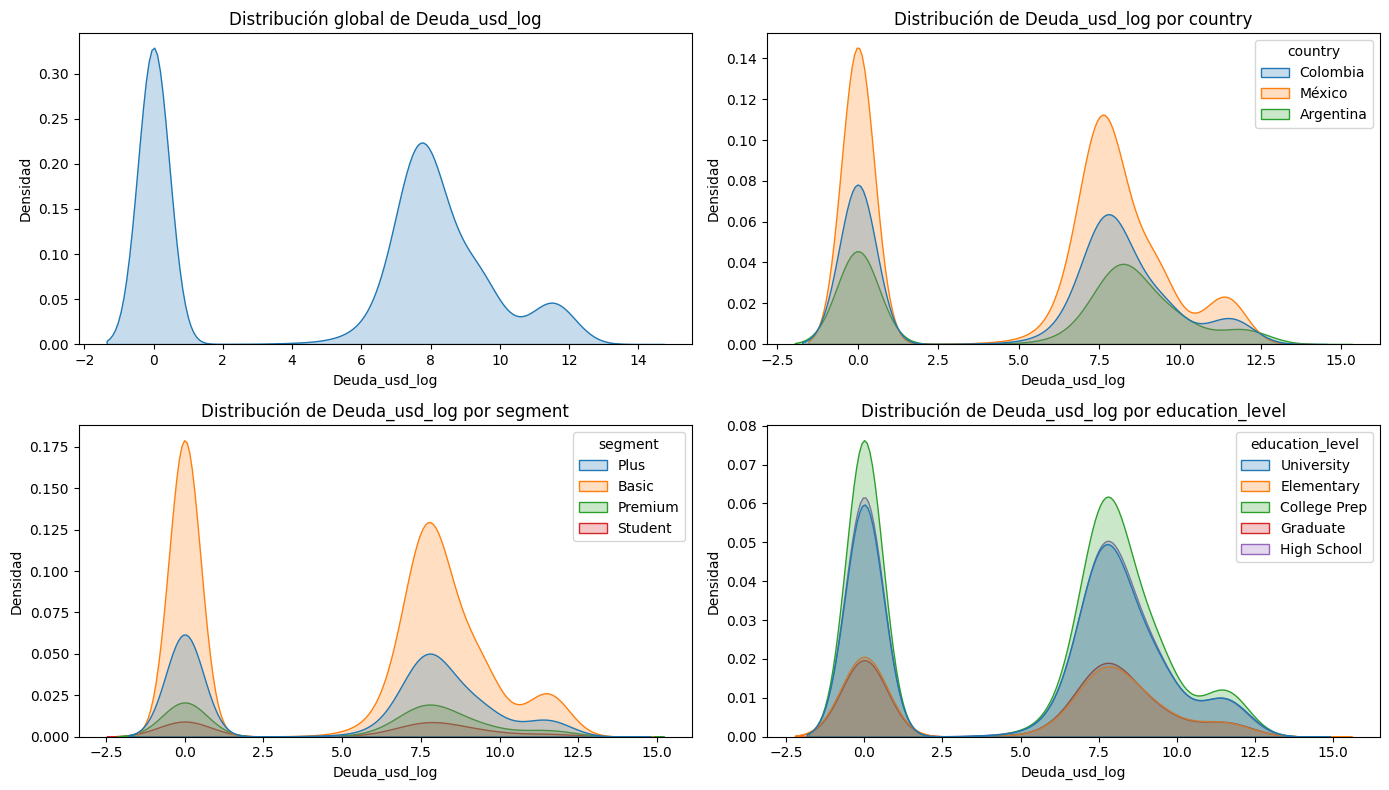


Distribución de Activos_financieros_usd_log por categorías:



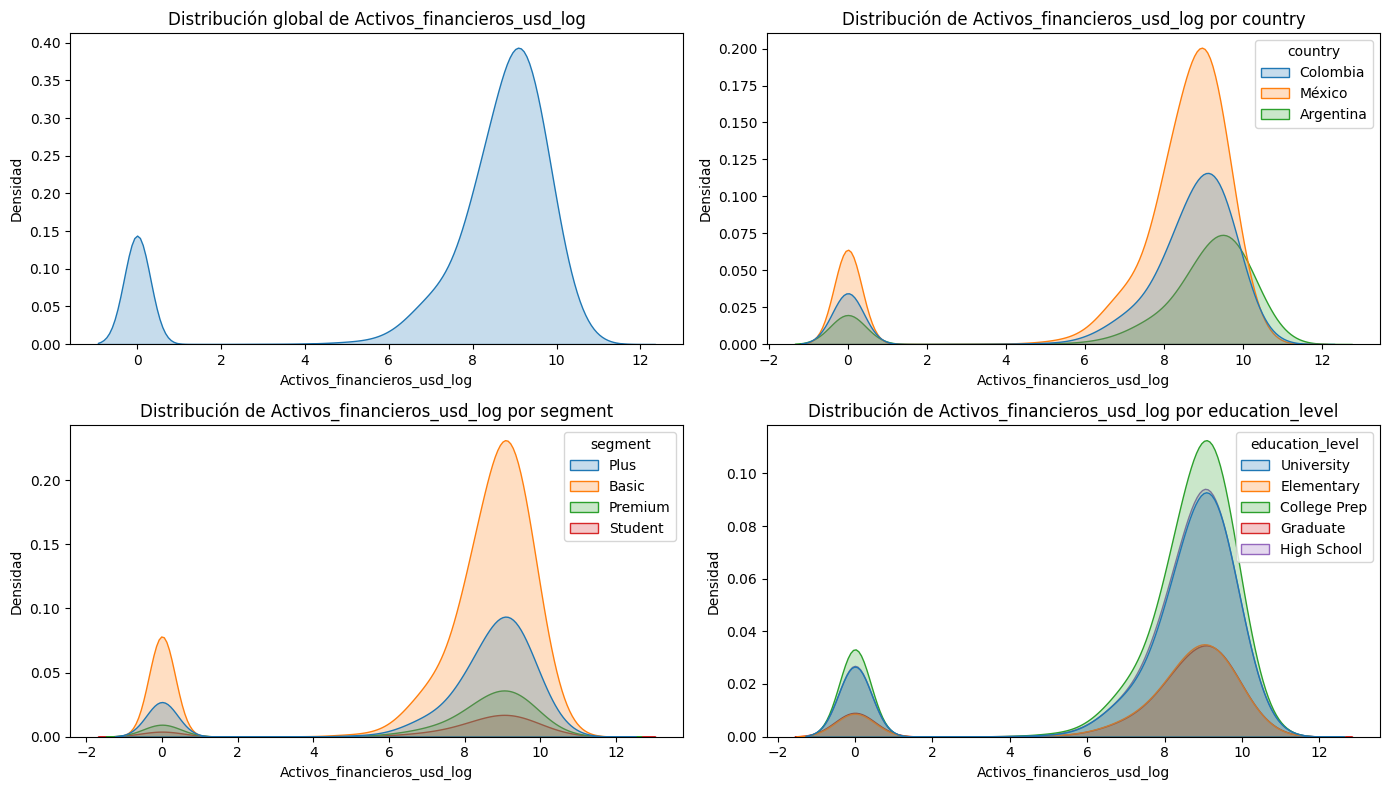

In [44]:
import numpy as np

df_model = df.copy()

financial_cols = [
    "income_usd",
    "credit_score",
    "Deuda_usd",
    "Activos_financieros_usd"
]

transformed_cols = [
    f"{col}_log" for col in financial_cols]

for col in financial_cols:
    df_model[f"{col}_log"] = np.log1p(
        df_model[col]
    )



for num_col in transformed_cols:
    print(f"\nDistribución de {num_col} por categorías:\n")

    fig, axs = plt.subplots(2, 2, figsize=(14, 8))


    # ============================================================
    # 1. Distribución global de income_usd
    # ============================================================

    sns.kdeplot(
        data=df_model,
        x=num_col,
        ax=axs[0][0],
        fill=True
    )

    axs[0][0].set_title("Distribución global de " + num_col)
    axs[0][0].set_xlabel(str(num_col))
    axs[0][0].set_ylabel("Densidad")



    sns.kdeplot(
        data=df_model,
        x=num_col,
        hue=hue_cols[0],
        ax=axs[0][1],
        fill=True,
        common_norm=True
    )

    axs[0][1].set_title("Distribución de {} por {}".format(num_col, hue_cols[0]))
    axs[0][1].set_xlabel(str(num_col))
    axs[0][1].set_ylabel("Densidad")


    sns.kdeplot(
        data=df_model,
        x=num_col,
        hue=hue_cols[1],
        ax=axs[1][0],
        fill=True,
        common_norm=True
    )

    axs[1][0].set_title("Distribución de {} por {}".format(num_col, hue_cols[1]))
    axs[1][0].set_xlabel(str(num_col))
    axs[1][0].set_ylabel("Densidad")


    # ============================================================
    # 4. Income por Education Level
    # ============================================================

    sns.kdeplot(
        data=df_model,
        x=num_col,
        hue=hue_cols[2],
        ax=axs[1][1],
        fill=True,
        common_norm=True
    )

    axs[1][1].set_title("Distribución de {} por {}".format(num_col, hue_cols[2]))
    axs[1][1].set_xlabel(str(num_col))
    axs[1][1].set_ylabel("Densidad")


    # ============================================================
    # Ajustar espacios
    # ============================================================

    plt.tight_layout()
    plt.show()



country: 50,001 observaciones utilizadas


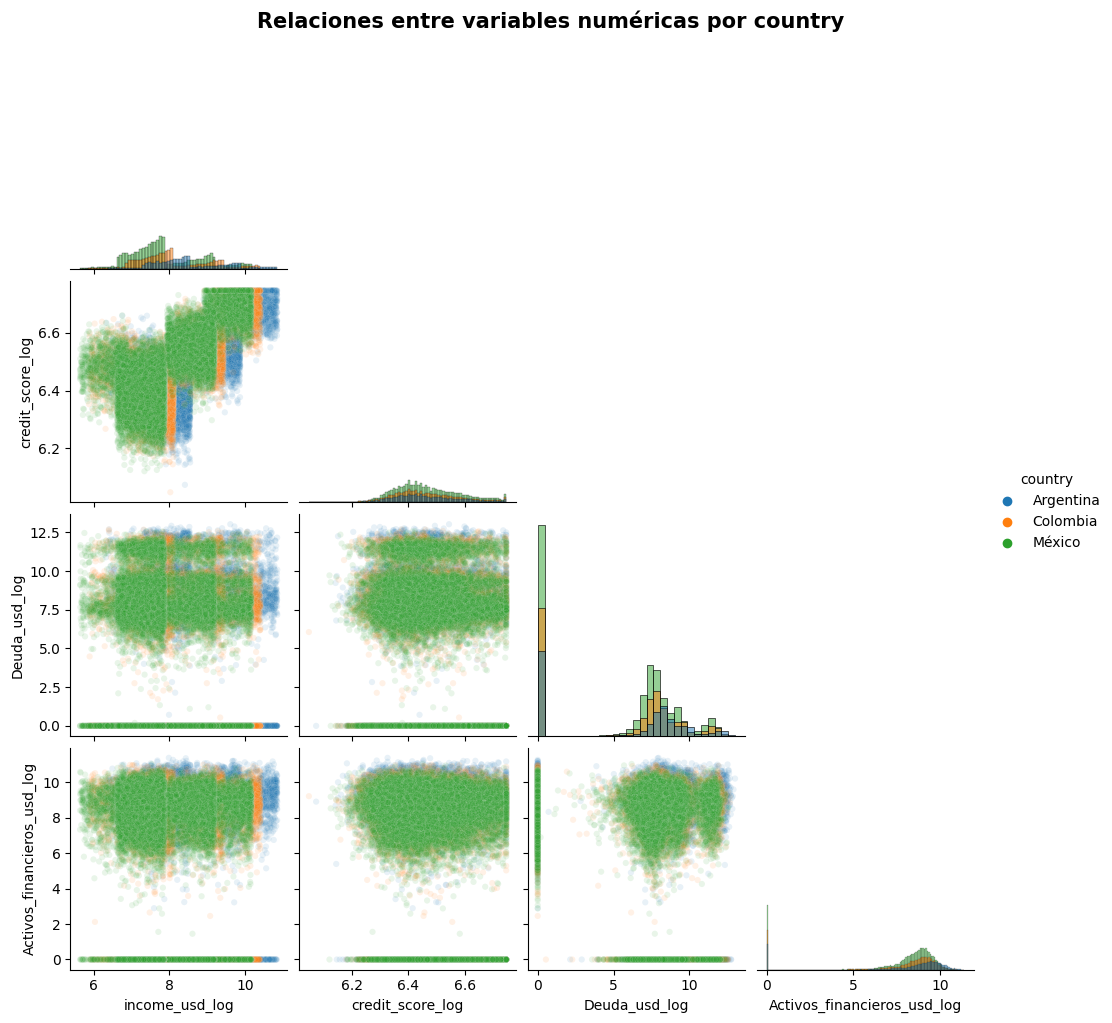

segment: 49,999 observaciones utilizadas


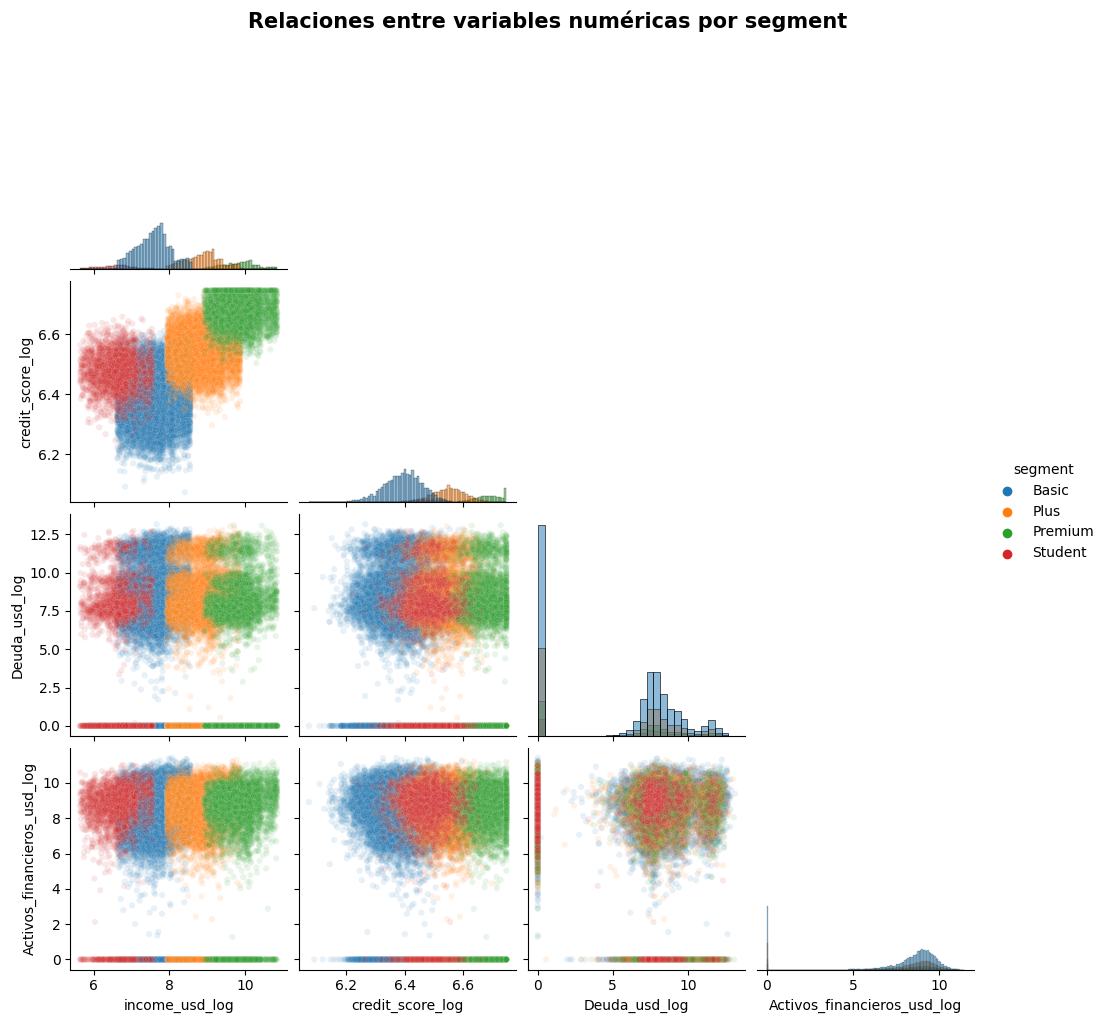

education_level: 50,000 observaciones utilizadas


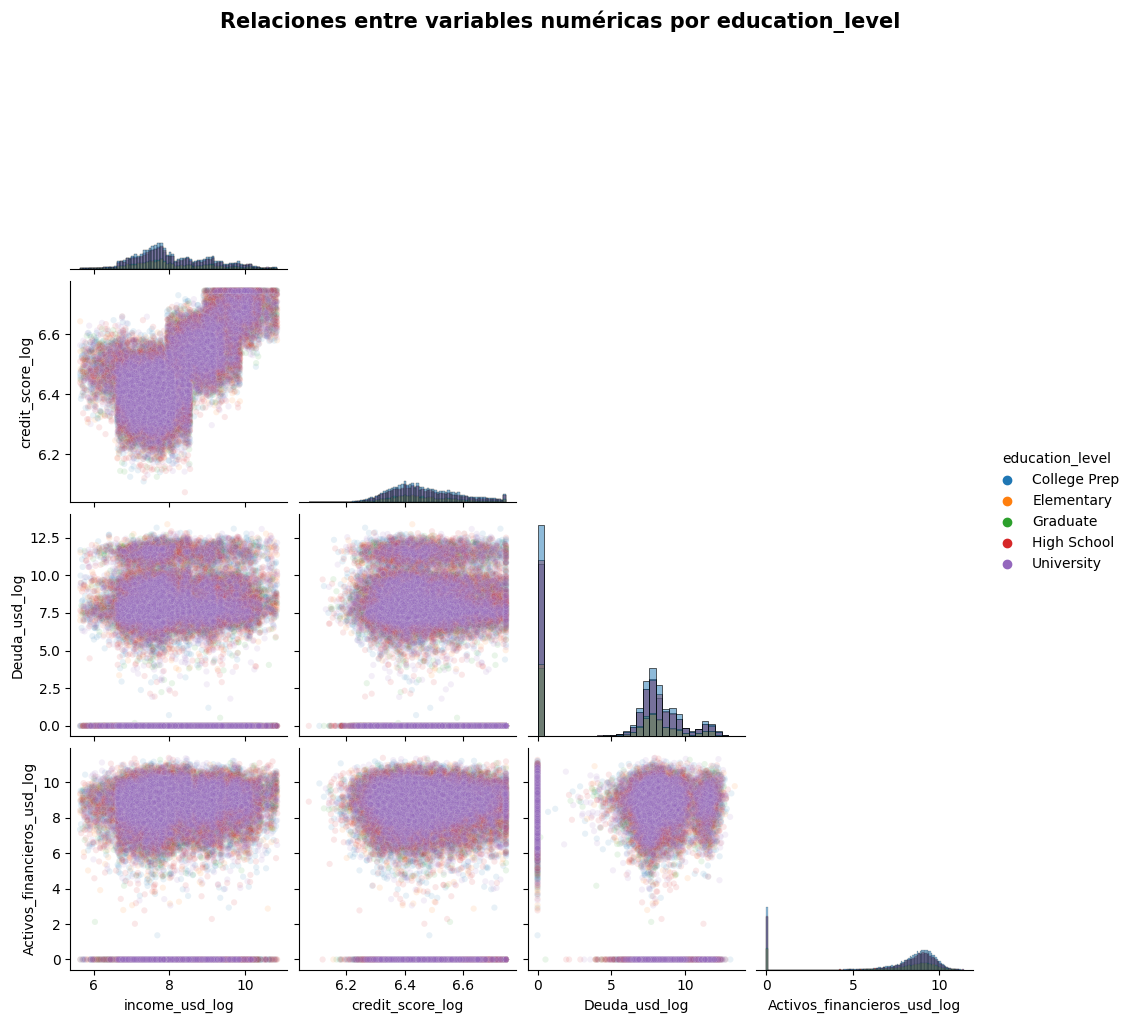

In [45]:

for categorical in [
    "country",
    "segment",
    "education_level"
]:
    


    plot_pairplot_by_hue(
        df_model,
        transformed_cols,
        categorical,
        sample_size=PAIRPLOT_SAMPLE,
        random_state=RANDOM_STATE
    )